In [1]:
!pip install xgboost shap imbalanced-learn scikit-learn matplotlib seaborn pandas numpy statsmodels openpyxl torch torchvision torchaudio

In [2]:
import os, time, warnings
warnings.filterwarnings('ignore')

# Data
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Machine Learning
from sklearn.model_selection   import train_test_split, StratifiedKFold
from sklearn.preprocessing     import StandardScaler
from sklearn.linear_model      import LogisticRegression
from sklearn.ensemble          import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    confusion_matrix, roc_curve, precision_recall_curve,
    matthews_corrcoef
)

# XGBoost
import xgboost as xgb

# SMOTE
from imblearn.over_sampling import SMOTE

# SHAP
import shap

# Statistical test
from statsmodels.stats.contingency_tables import mcnemar

# Deep Learning (PyTorch)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

print("=" * 60)
print("  ✅  ALL LIBRARIES LOADED")
print("=" * 60)
print(f"  XGBoost   : {xgb.__version__}")
print(f"  PyTorch   : {torch.__version__}")
print(f"  SHAP      : {shap.__version__}")
print(f"  Pandas    : {pd.__version__}")
print("=" * 60)
print("\n  GPU available:", torch.cuda.is_available())
print("  Device used  :", "GPU" if torch.cuda.is_available() else "CPU (fine for this)")
print("\n👉 Run SECTION 1 next.")


  ✅  ALL LIBRARIES LOADED
  XGBoost   : 3.2.0
  PyTorch   : 2.11.0+cpu
  SHAP      : 0.51.0
  Pandas    : 2.3.3

  GPU available: False
  Device used  : CPU (fine for this)

👉 Run SECTION 1 next.


In [3]:

# ─── CHANGE THIS PATH TO YOUR FOLDER ──────────────────────────────────────
BASE_PATH = 'D:/Credit-Card/Datasets/'
# ──────────────────────────────────────────────────────────────────────────

SAVE_PATH = BASE_PATH          # all figures and CSV files save here
os.makedirs(SAVE_PATH, exist_ok=True)

# Dataset file names (change only if your files are named differently)
D1_FILE = 'creditcard.csv'     # Kaggle Credit Card Fraud
D2_FILE = 'fraudTest.csv'      # Online Transaction Fraud
D3_FILE = 'PS.csv'             # PaySim Mobile Money

print("=" * 60)
print("  LOADING DATASETS")
print("=" * 60)

def load_csv(path, name):
    """Loads a CSV and prints a summary."""
    if not os.path.exists(path):
        print(f"\n❌ NOT FOUND: {path}")
        print("   Check BASE_PATH and file name.")
        return None
    df = pd.read_csv(path)
    print(f"\n✅ {name} loaded")
    print(f"   File  : {path.split('/')[-1]}")
    print(f"   Shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
    print(f"   Cols  : {list(df.columns[:6])} ...")
    return df

df1 = load_csv(BASE_PATH + D1_FILE, "Dataset 1 — Kaggle CC Fraud")
df2 = load_csv(BASE_PATH + D2_FILE, "Dataset 2 — Online Fraud")
df3 = load_csv(BASE_PATH + D3_FILE, "Dataset 3 — PaySim")

print("\n👉 Run SECTION 2 next.")


  LOADING DATASETS

✅ Dataset 1 — Kaggle CC Fraud loaded
   File  : creditcard.csv
   Shape : 284,807 rows × 31 columns
   Cols  : ['Time', 'V1', 'V2', 'V3', 'V4', 'V5'] ...

✅ Dataset 2 — Online Fraud loaded
   File  : fraudTest.csv
   Shape : 555,719 rows × 23 columns
   Cols  : ['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt'] ...

✅ Dataset 3 — PaySim loaded
   File  : PS.csv
   Shape : 5,840,046 rows × 11 columns
   Cols  : ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig'] ...

👉 Run SECTION 2 next.


In [4]:

print("=" * 60)
print("  SECTION 2 — DATA PREPARATION")
print("=" * 60)

# ─────────────────────────────────────────────────
# DATASET 1 — Kaggle Credit Card Fraud
# Columns: Time, V1-V28 (PCA), Amount, Class
# ─────────────────────────────────────────────────
print("\n── Dataset 1: Kaggle Credit Card Fraud ──")
d1 = df1.copy()

# Remove duplicates
n_before = len(d1)
d1.drop_duplicates(inplace=True)
print(f"  Duplicates removed : {n_before - len(d1):,}")

# Missing values
print(f"  Missing values     : {d1.isnull().sum().sum()}")

# Scale Amount and Time (V1-V28 already PCA-scaled)
sc1 = StandardScaler()
d1['Amount'] = sc1.fit_transform(d1[['Amount']])
d1['Time']   = sc1.fit_transform(d1[['Time']])

X1 = d1.drop('Class', axis=1)
y1 = d1['Class']

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42, stratify=y1
)

fraud_pct = y1.mean() * 100
print(f"  Fraud rate         : {fraud_pct:.4f}%")
print(f"  Train size         : {len(y1_train):,}  |  Test size: {len(y1_test):,}")
print(f"  Train fraud count  : {y1_train.sum():,}  |  Test fraud: {y1_test.sum():,}")


# ─────────────────────────────────────────────────
# DATASET 2 — Online Transaction Fraud (fraudTest.csv)
# Typical columns: step, type, amount, nameOrig,
#   oldbalanceOrg, newbalanceOrig, nameDest,
#   oldbalanceDest, newbalanceDest, isFraud
# ─────────────────────────────────────────────────
print("\n── Dataset 2: Online Transaction Fraud ──")
d2 = df2.copy()

# Remove duplicates
n_before = len(d2)
d2.drop_duplicates(inplace=True)
print(f"  Duplicates removed : {n_before - len(d2):,}")

# Missing values
print(f"  Missing values     : {d2.isnull().sum().sum()}")

# Auto-detect fraud label column
label_col_d2 = None
for c in ['isFraud', 'fraud', 'Fraud', 'Class', 'label', 'is_fraud']:
    if c in d2.columns:
        label_col_d2 = c
        break
if label_col_d2 is None:
    print(f"  ⚠️  Columns: {list(d2.columns)}")
    print("  Set label_col_d2 manually below!")
    label_col_d2 = 'isFraud'   # ← change if needed

print(f"  Fraud label column : '{label_col_d2}'")

# Encode text columns
for col in d2.select_dtypes(include='object').columns:
    if col not in [label_col_d2]:
        d2[col] = pd.factorize(d2[col])[0]
        print(f"  Encoded text col   : {col}")

# Drop ID-like string columns that can't help prediction
drop_cols = ['nameOrig', 'nameDest', 'isFlaggedFraud']
drop_cols = [c for c in drop_cols if c in d2.columns]
d2.drop(drop_cols, axis=1, inplace=True)

# Handle missing values by filling with median
d2.fillna(d2.median(numeric_only=True), inplace=True)

# Sample if too large (keep ALL fraud + sample normal)
MAX_D2 = 300000
if len(d2) > MAX_D2:
    fraud_d2  = d2[d2[label_col_d2] == 1]
    normal_d2 = d2[d2[label_col_d2] == 0].sample(
        n=min(MAX_D2 - len(fraud_d2), len(d2[d2[label_col_d2]==0])),
        random_state=42
    )
    d2 = pd.concat([fraud_d2, normal_d2]).sample(frac=1, random_state=42).reset_index(drop=True)
    print(f"  Sampled to         : {len(d2):,} rows (kept all {len(fraud_d2):,} fraud)")

# Scale
sc2 = StandardScaler()
num_cols_d2 = d2.select_dtypes(include=np.number).columns.tolist()
num_cols_d2 = [c for c in num_cols_d2 if c != label_col_d2]
d2[num_cols_d2] = sc2.fit_transform(d2[num_cols_d2])

X2 = d2.drop(label_col_d2, axis=1)
y2 = d2[label_col_d2].astype(int)

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

fraud_pct2 = y2.mean() * 100
print(f"  Fraud rate         : {fraud_pct2:.4f}%")
print(f"  Train size         : {len(y2_train):,}  |  Test size: {len(y2_test):,}")
print(f"  Train fraud count  : {y2_train.sum():,}  |  Test fraud: {y2_test.sum():,}")


# ─────────────────────────────────────────────────
# DATASET 3 — PaySim (PS.csv)
# Columns: step, type, amount, nameOrig,
#   oldbalanceOrg, newbalanceOrig, nameDest,
#   oldbalanceDest, newbalanceDest, isFraud, isFlaggedFraud
# ─────────────────────────────────────────────────
print("\n── Dataset 3: PaySim Mobile Money ──")
d3 = df3.copy()

n_before = len(d3)
d3.drop_duplicates(inplace=True)
print(f"  Duplicates removed : {n_before - len(d3):,}")
print(f"  Missing values     : {d3.isnull().sum().sum()}")

# Encode transaction type
if 'type' in d3.columns:
    d3['type'] = pd.factorize(d3['type'])[0]

# Drop ID and leakage columns
drop3 = ['nameOrig', 'nameDest', 'isFlaggedFraud']
drop3 = [c for c in drop3 if c in d3.columns]
d3.drop(drop3, axis=1, inplace=True)

# Sample if needed
label_col_d3 = 'isFraud'
MAX_D3 = 200000
if len(d3) > MAX_D3:
    fraud_d3  = d3[d3[label_col_d3] == 1]
    normal_d3 = d3[d3[label_col_d3] == 0].sample(
        n=min(MAX_D3 - len(fraud_d3), len(d3[d3[label_col_d3]==0])),
        random_state=42
    )
    d3 = pd.concat([fraud_d3, normal_d3]).sample(frac=1, random_state=42).reset_index(drop=True)
    print(f"  Sampled to         : {len(d3):,} rows")

# Scale
sc3 = StandardScaler()
num_cols_d3 = d3.select_dtypes(include=np.number).columns.tolist()
num_cols_d3 = [c for c in num_cols_d3 if c != label_col_d3]
d3[num_cols_d3] = sc3.fit_transform(d3[num_cols_d3])

X3 = d3.drop(label_col_d3, axis=1)
y3 = d3[label_col_d3].astype(int)

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.2, random_state=42, stratify=y3
)

fraud_pct3 = y3.mean() * 100
print(f"  Fraud rate         : {fraud_pct3:.4f}%")
print(f"  Train size         : {len(y3_train):,}  |  Test size: {len(y3_test):,}")
print(f"  Train fraud count  : {y3_train.sum():,}  |  Test fraud: {y3_test.sum():,}")

# Bundle into a list for easy looping later
datasets = [
    {'name':'D1 (Kaggle CC)', 'X_train':X1_train,'X_test':X1_test,
     'y_train':y1_train,'y_test':y1_test},
    {'name':'D2 (Online Fraud)','X_train':X2_train,'X_test':X2_test,
     'y_train':y2_train,'y_test':y2_test},
    {'name':'D3 (PaySim)',   'X_train':X3_train,'X_test':X3_test,
     'y_train':y3_train,'y_test':y3_test},
]

print("\n✅ All 3 datasets prepared.")
print("👉 Run SECTION 3 next.")


  SECTION 2 — DATA PREPARATION

── Dataset 1: Kaggle Credit Card Fraud ──
  Duplicates removed : 1,081
  Missing values     : 0
  Fraud rate         : 0.1667%
  Train size         : 226,980  |  Test size: 56,746
  Train fraud count  : 378  |  Test fraud: 95

── Dataset 2: Online Transaction Fraud ──
  Duplicates removed : 0
  Missing values     : 0
  Fraud label column : 'is_fraud'
  Encoded text col   : trans_date_trans_time
  Encoded text col   : merchant
  Encoded text col   : category
  Encoded text col   : first
  Encoded text col   : last
  Encoded text col   : gender
  Encoded text col   : street
  Encoded text col   : city
  Encoded text col   : state
  Encoded text col   : job
  Encoded text col   : dob
  Encoded text col   : trans_num
  Sampled to         : 300,000 rows (kept all 2,145 fraud)
  Fraud rate         : 0.7150%
  Train size         : 240,000  |  Test size: 60,000
  Train fraud count  : 1,716  |  Test fraud: 429

── Dataset 3: PaySim Mobile Money ──
  Duplicates re

In [5]:
print("=" * 60)
print("  SECTION 3 — APPLYING SMOTE")
print("=" * 60)
print("⚠️  Applying to TRAINING data ONLY\n")

smote = SMOTE(random_state=42, k_neighbors=5)

for ds in datasets:
    name = ds['name']
    print(f"  Processing {name}...")
    t0 = time.time()
    X_sm, y_sm = smote.fit_resample(ds['X_train'], ds['y_train'])
    elapsed = time.time() - t0
    ds['X_train_sm'] = X_sm
    ds['y_train_sm'] = y_sm
    ds['smote_time'] = elapsed

    before_fraud = ds['y_train'].sum()
    after_fraud  = pd.Series(y_sm).sum()
    print(f"    Before SMOTE: {len(ds['y_train']):,} rows  |  Fraud: {before_fraud:,}")
    print(f"    After  SMOTE: {len(y_sm):,} rows  |  Fraud: {after_fraud:,}")
    print(f"    Time: {elapsed:.1f}s\n")

print("✅ SMOTE complete for all 3 datasets.")
print("👉 Run SECTION 4 next.")


  SECTION 3 — APPLYING SMOTE
⚠️  Applying to TRAINING data ONLY

  Processing D1 (Kaggle CC)...
    Before SMOTE: 226,980 rows  |  Fraud: 378
    After  SMOTE: 453,204 rows  |  Fraud: 226,602
    Time: 5.9s

  Processing D2 (Online Fraud)...
    Before SMOTE: 240,000 rows  |  Fraud: 1,716
    After  SMOTE: 476,568 rows  |  Fraud: 238,284
    Time: 0.4s

  Processing D3 (PaySim)...
    Before SMOTE: 160,000 rows  |  Fraud: 3,598
    After  SMOTE: 312,804 rows  |  Fraud: 156,402
    Time: 0.1s

✅ SMOTE complete for all 3 datasets.
👉 Run SECTION 4 next.


In [6]:
print("=" * 60)
print("  SECTION 4 — TRAINING TREE MODELS (A, B, C, D)")
print("=" * 60)

# XGBoost settings (same for all datasets)
XGB_PARAMS = dict(
    n_estimators    = 200,
    max_depth       = 6,
    learning_rate   = 0.1,
    subsample       = 0.8,
    colsample_bytree= 0.8,
    eval_metric     = 'logloss',
    random_state    = 42,
    n_jobs          = -1
)

def train_model(model, X_tr, y_tr, label):
    """Trains a model, prints time, returns (model, time_seconds)."""
    print(f"    Training: {label} ...", end=' ', flush=True)
    t0 = time.time()
    model.fit(X_tr, y_tr)
    elapsed = time.time() - t0
    print(f"✅ {elapsed:.1f}s")
    return model, elapsed

for ds in datasets:
    name = ds['name']
    print(f"\n─── {name} ───")

    ds['model_A'], ds['time_A'] = train_model(
        xgb.XGBClassifier(**XGB_PARAMS),
        ds['X_train'], ds['y_train'],
        "Model A: XGBoost (no SMOTE)"
    )
    ds['model_B'], ds['time_B'] = train_model(
        xgb.XGBClassifier(**XGB_PARAMS),
        ds['X_train_sm'], ds['y_train_sm'],
        "Model B: XGBoost + SMOTE  ← MAIN"
    )
    ds['model_C'], ds['time_C'] = train_model(
        LogisticRegression(max_iter=1000, random_state=42),
        ds['X_train_sm'], ds['y_train_sm'],
        "Model C: Logistic Regression + SMOTE"
    )
    ds['model_D'], ds['time_D'] = train_model(
        RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
        ds['X_train_sm'], ds['y_train_sm'],
        "Model D: Random Forest + SMOTE"
    )

print("\n✅ All tree models trained.")
print("👉 Run SECTION 5 next.")


  SECTION 4 — TRAINING TREE MODELS (A, B, C, D)

─── D1 (Kaggle CC) ───
    Training: Model A: XGBoost (no SMOTE) ... ✅ 8.4s
    Training: Model B: XGBoost + SMOTE  ← MAIN ... ✅ 15.6s
    Training: Model C: Logistic Regression + SMOTE ... ✅ 2.4s
    Training: Model D: Random Forest + SMOTE ... ✅ 243.3s

─── D2 (Online Fraud) ───
    Training: Model A: XGBoost (no SMOTE) ... ✅ 7.8s
    Training: Model B: XGBoost + SMOTE  ← MAIN ... ✅ 14.1s
    Training: Model C: Logistic Regression + SMOTE ... ✅ 2.3s
    Training: Model D: Random Forest + SMOTE ... ✅ 163.8s

─── D3 (PaySim) ───
    Training: Model A: XGBoost (no SMOTE) ... ✅ 3.4s
    Training: Model B: XGBoost + SMOTE  ← MAIN ... ✅ 6.4s
    Training: Model C: Logistic Regression + SMOTE ... ✅ 1.2s
    Training: Model D: Random Forest + SMOTE ... ✅ 28.9s

✅ All tree models trained.
👉 Run SECTION 5 next.


In [11]:
# ==============================================================================
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  SECTION 5 — DEFINE AND TRAIN DEEP MODELS (E1, E2, E3, E4)            ║
# ╚══════════════════════════════════════════════════════════════════════════╝
# What this does:
#   Builds a Multi-Layer Perceptron (MLP) neural network.
#   Trains 4 versions to compare loss functions and SMOTE effect:
#
#   Model E1 — MLP + Cross-Entropy,            NO SMOTE
#   Model E2 — MLP + Focal Loss,               NO SMOTE
#   Model E3 — MLP + Cross-Entropy +  SMOTE
#   Model E4 — MLP + Focal Loss    +  SMOTE    ← MAIN DEEP MODEL
#
#   What is Focal Loss?
#     Normal Cross-Entropy treats all mistakes equally.
#     Focal Loss puts MORE attention on the hard cases (the rare fraud).
#     This is exactly what Albalawi & Dardouri used — you are matching
#     and extending their approach by also testing with SMOTE.
#
#   What is an MLP?
#     A simple feed-forward neural network.
#     Input → Hidden Layer 1 → Hidden Layer 2 → Output (fraud probability)
# ==============================================================================

print("=" * 60)
print("  SECTION 5 — DEEP MODEL ARCHITECTURE")
print("=" * 60)

# ─── MLP Architecture ──────────────────────────────────────────────────────
class FraudMLP(nn.Module):
    """
    Multi-Layer Perceptron for binary fraud detection.
    Architecture:
      Input → Dense(128) → BatchNorm → ReLU → Dropout(0.3)
            → Dense(64)  → BatchNorm → ReLU → Dropout(0.3)
            → Dense(32)  → ReLU
            → Dense(1)   → Sigmoid
    """
    def __init__(self, input_dim):
        super(FraudMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)


# ─── Focal Loss ────────────────────────────────────────────────────────────
class FocalLoss(nn.Module):
    """
    Focal Loss: focuses learning on hard-to-classify fraud cases.
    alpha (0.25): weight for positive class (fraud)
    gamma (2.0):  focusing parameter — higher = more focus on hard cases
    """
    def __init__(self, alpha=0.25, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, preds, targets):
        # FIX: Ensure targets have same shape as preds
        # preds shape: (batch, 1), targets shape: (batch,)
        # Reshape targets to (batch, 1) to match preds
        if len(targets.shape) == 1:
            targets = targets.unsqueeze(1)  # Add dimension: (batch,) -> (batch, 1)
        
        BCE = nn.functional.binary_cross_entropy(preds, targets, reduction='none')
        pt = torch.exp(-BCE)  # probability of correct class
        focal = self.alpha * (1 - pt)**self.gamma * BCE
        return focal.mean()


# ─── Training Function ─────────────────────────────────────────────────────
DEVICE    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
N_EPOCHS  = 50       # max training rounds
BATCH_SIZE= 512      # rows per training batch
LR        = 0.001    # learning rate
PATIENCE  = 8        # stop if no improvement for 8 epochs

def train_mlp(X_tr, y_tr, X_val, y_val, loss_fn, model_label, input_dim):
    """
    Trains one MLP with early stopping.
    Returns: (trained_model, train_time_seconds, history_dict)
    """
    # Convert to PyTorch tensors
    X_tr_t  = torch.FloatTensor(np.array(X_tr)).to(DEVICE)
    y_tr_t  = torch.FloatTensor(np.array(y_tr)).to(DEVICE)
    X_val_t = torch.FloatTensor(np.array(X_val)).to(DEVICE)
    y_val_t = torch.FloatTensor(np.array(y_val)).to(DEVICE)

    # FIX: Ensure validation labels have correct shape for loss computation
    # Reshape to (n_samples, 1) if needed
    if len(y_val_t.shape) == 1:
        y_val_t_for_loss = y_val_t.unsqueeze(1)
    else:
        y_val_t_for_loss = y_val_t

    loader = DataLoader(
        TensorDataset(X_tr_t, y_tr_t),
        batch_size=BATCH_SIZE, shuffle=True
    )

    model     = FraudMLP(input_dim).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

    history   = {'train_loss': [], 'val_loss': [], 'val_recall': []}
    best_loss = float('inf')
    best_wts  = None
    patience_counter = 0

    print(f"    Training: {model_label} ...", end=' ', flush=True)
    t0 = time.time()

    for epoch in range(N_EPOCHS):
        # Training pass
        model.train()
        epoch_loss = 0
        for X_b, y_b in loader:
            optimizer.zero_grad()
            out = model(X_b)
            
            # FIX: Ensure targets have same shape as predictions for loss computation
            if len(y_b.shape) == 1:
                y_b_for_loss = y_b.unsqueeze(1)
            else:
                y_b_for_loss = y_b
                
            loss = loss_fn(out, y_b_for_loss)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        # Validation pass
        model.eval()
        with torch.no_grad():
            val_out = model(X_val_t)
            
            # FIX: Ensure validation targets have correct shape for loss computation
            if len(y_val_t_for_loss.shape) == 1:
                y_val_t_for_loss = y_val_t_for_loss.unsqueeze(1)
                
            val_loss = loss_fn(val_out, y_val_t_for_loss).item()
            
            # For recall calculation, squeeze predictions to 1D
            val_pred = (val_out.squeeze().cpu().numpy() >= 0.5).astype(int)
            # Convert y_val to numpy if it's a pandas Series/DataFrame
            y_val_np = y_val.values if hasattr(y_val, 'values') else np.array(y_val)
            val_rec = recall_score(y_val_np, val_pred, zero_division=0)

        history['train_loss'].append(epoch_loss / len(loader))
        history['val_loss'].append(val_loss)
        history['val_recall'].append(val_rec)

        scheduler.step(val_loss)

        # Early stopping
        if val_loss < best_loss:
            best_loss = val_loss
            best_wts  = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                break

    # Restore best weights
    if best_wts:
        model.load_state_dict(best_wts)

    elapsed = time.time() - t0
    print(f"✅ {elapsed:.1f}s  (stopped at epoch {epoch+1})")
    return model, elapsed, history


# ─── Train Deep Models on All 3 Datasets ───────────────────────────────────
print("\n  Training deep models on all 3 datasets...")
print(f"  Device: {DEVICE}\n")

ce_loss = nn.BCELoss()
focal_loss = FocalLoss(alpha=0.25, gamma=2.0)

# FIX: Add a wrapper for BCELoss to handle shape mismatches
class BCEWithShapeCheck(nn.Module):
    """
    Wrapper for BCELoss that automatically reshapes targets to match predictions.
    """
    def __init__(self):
        super(BCEWithShapeCheck, self).__init__()
        self.bce = nn.BCELoss()
    
    def forward(self, preds, targets):
        # Ensure targets have same shape as preds
        if len(targets.shape) == 1:
            targets = targets.unsqueeze(1)
        return self.bce(preds, targets)

# Use the wrapped BCE loss
ce_loss_wrapped = BCEWithShapeCheck()

for ds in datasets:
    name      = ds['name']
    input_dim = ds['X_train'].shape[1]
    print(f"\n─── {name} (input_dim={input_dim}) ───")

    # Split off a small validation set from training (for early stopping only)
    X_tr_raw = ds['X_train']
    y_tr_raw = ds['y_train']
    X_tr_sm  = ds['X_train_sm']
    y_tr_sm  = ds['y_train_sm']

    X_tr_raw_t, X_val_t, y_tr_raw_t, y_val_t = train_test_split(
        X_tr_raw, y_tr_raw, test_size=0.15, random_state=42, stratify=y_tr_raw
    )
    X_tr_sm_t, X_val_sm_t, y_tr_sm_t, y_val_sm_t = train_test_split(
        X_tr_sm, pd.Series(y_tr_sm), test_size=0.15, random_state=42,
        stratify=y_tr_sm
    )

    # Model E1 — MLP + Cross-Entropy (no SMOTE)
    ds['model_E1'], ds['time_E1'], ds['hist_E1'] = train_mlp(
        X_tr_raw_t, y_tr_raw_t, X_val_t, y_val_t,
        ce_loss_wrapped, "Model E1: MLP + CE (no SMOTE)", input_dim
    )

    # Model E2 — MLP + Focal Loss (no SMOTE)
    ds['model_E2'], ds['time_E2'], ds['hist_E2'] = train_mlp(
        X_tr_raw_t, y_tr_raw_t, X_val_t, y_val_t,
        focal_loss, "Model E2: MLP + Focal (no SMOTE)", input_dim
    )

    # Model E3 — MLP + Cross-Entropy + SMOTE
    ds['model_E3'], ds['time_E3'], ds['hist_E3'] = train_mlp(
        X_tr_sm_t, y_tr_sm_t, X_val_sm_t, y_val_sm_t,
        ce_loss_wrapped, "Model E3: MLP + CE + SMOTE", input_dim
    )

    # Model E4 — MLP + Focal Loss + SMOTE  ← MAIN DEEP MODEL
    ds['model_E4'], ds['time_E4'], ds['hist_E4'] = train_mlp(
        X_tr_sm_t, y_tr_sm_t, X_val_sm_t, y_val_sm_t,
        focal_loss, "Model E4: MLP + Focal + SMOTE ← MAIN", input_dim
    )

print("\n✅ All deep models trained.")
print("👉 Run SECTION 6 next.")

  SECTION 5 — DEEP MODEL ARCHITECTURE

  Training deep models on all 3 datasets...
  Device: cpu


─── D1 (Kaggle CC) (input_dim=30) ───
    Training: Model E1: MLP + CE (no SMOTE) ... ✅ 168.8s  (stopped at epoch 28)
    Training: Model E2: MLP + Focal (no SMOTE) ... ✅ 251.9s  (stopped at epoch 29)
    Training: Model E3: MLP + CE + SMOTE ... ✅ 951.9s  (stopped at epoch 50)
    Training: Model E4: MLP + Focal + SMOTE ← MAIN ... ✅ 1965.2s  (stopped at epoch 49)

─── D2 (Online Fraud) (input_dim=22) ───
    Training: Model E1: MLP + CE (no SMOTE) ... ✅ 341.5s  (stopped at epoch 50)
    Training: Model E2: MLP + Focal (no SMOTE) ... ✅ 654.3s  (stopped at epoch 50)
    Training: Model E3: MLP + CE + SMOTE ... ✅ 711.7s  (stopped at epoch 50)
    Training: Model E4: MLP + Focal + SMOTE ← MAIN ... ✅ 785.9s  (stopped at epoch 50)

─── D3 (PaySim) (input_dim=7) ───
    Training: Model E1: MLP + CE (no SMOTE) ... ✅ 130.1s  (stopped at epoch 26)
    Training: Model E2: MLP + Focal (no SMOTE) ... 

In [12]:
# ==============================================================================
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  SECTION 6 — EVALUATE ALL MODELS (ALL METRICS)                        ║
# ╚══════════════════════════════════════════════════════════════════════════╝
# What this does:
#   For EVERY model (A, B, C, D, E1-E4) on EVERY dataset (D1, D2, D3):
#     1. Makes predictions on the real imbalanced test set
#     2. Computes all 8 metrics
#     3. Measures inference latency (how fast it predicts)
#     4. Saves everything to results_table.csv
#
#   KEY RULE: All metrics are computed on the ORIGINAL test set
#   (no SMOTE on test) — this is honest, real-world evaluation.
# ==============================================================================

print("=" * 60)
print("  SECTION 6 — EVALUATING ALL MODELS")
print("=" * 60)

def evaluate_sklearn(model, X_test, y_test, model_name, ds_name):
    """Evaluates a scikit-learn model."""
    t0 = time.time()
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    lat_s  = (time.time() - t0) / len(y_test)   # seconds per sample
    lat_ms = lat_s * 1000                         # ms per sample

    return _make_result(y_test, y_pred, y_prob,
                        model_name, ds_name, lat_ms,
                        getattr(model, '_train_time', 0))


def evaluate_mlp(model, X_test, y_test, model_name, ds_name):
    """Evaluates a PyTorch MLP model."""
    model.eval()
    X_t = torch.FloatTensor(np.array(X_test)).to(DEVICE)
    t0  = time.time()
    with torch.no_grad():
        probs = model(X_t).squeeze().cpu().numpy()
    lat_s  = (time.time() - t0) / len(y_test)
    lat_ms = lat_s * 1000

    y_pred = (probs >= 0.5).astype(int)
    return _make_result(y_test, y_pred, probs,
                        model_name, ds_name, lat_ms, 0)


def _make_result(y_test, y_pred, y_prob, model_name, ds_name, lat_ms, train_s):
    """Computes all metrics and returns a dict."""
    y_test_arr = np.array(y_test)
    acc  = accuracy_score(y_test_arr, y_pred)
    prec = precision_score(y_test_arr, y_pred, zero_division=0)
    rec  = recall_score(y_test_arr, y_pred, zero_division=0)
    f1   = f1_score(y_test_arr, y_pred, zero_division=0)
    roc  = roc_auc_score(y_test_arr, y_prob)
    pr   = average_precision_score(y_test_arr, y_prob)
    mcc  = matthews_corrcoef(y_test_arr, y_pred)
    cm   = confusion_matrix(y_test_arr, y_pred)

    # Fix latency display — never show 0.0
    if lat_ms < 0.001:
        lat_display = f"~{lat_ms*1000:.2f} μs"
    elif lat_ms < 1.0:
        lat_display = f"~{lat_ms:.4f} ms"
    else:
        lat_display = f"{lat_ms:.2f} ms"

    return {
        'Dataset': ds_name, 'Model': model_name,
        'Accuracy': acc, 'Precision': prec, 'Recall': rec,
        'F1': f1, 'ROC_AUC': roc, 'PR_AUC': pr, 'MCC': mcc,
        'TrainTime_s': round(train_s, 2),
        'Latency_ms': lat_ms,
        'Latency_display': lat_display,
        'cm': cm, 'y_pred': y_pred, 'y_prob': y_prob
    }


all_results = []

for ds in datasets:
    name  = ds['name']
    X_te  = ds['X_test']
    y_te  = ds['y_test']
    print(f"\n─── Evaluating {name} ───")

    for label, model_key, time_key, is_deep in [
        ('A: XGBoost (no SMOTE)',      'model_A','time_A', False),
        ('B: SMOTE+XGBoost',           'model_B','time_B', False),
        ('C: LogReg+SMOTE',            'model_C','time_C', False),
        ('D: RF+SMOTE',                'model_D','time_D', False),
        ('E1: MLP+CE (no SMOTE)',      'model_E1','time_E1', True),
        ('E2: MLP+Focal (no SMOTE)',   'model_E2','time_E2', True),
        ('E3: MLP+CE+SMOTE',           'model_E3','time_E3', True),
        ('E4: MLP+Focal+SMOTE',        'model_E4','time_E4', True),
    ]:
        if is_deep:
            r = evaluate_mlp(ds[model_key], X_te, y_te, label, name)
        else:
            r = evaluate_sklearn(ds[model_key], X_te, y_te, label, name)
        r['TrainTime_s'] = round(ds[time_key], 2)
        all_results.append(r)
        print(f"  {label:35s}  Recall={r['Recall']:.3f}  "
              f"F1={r['F1']:.3f}  MCC={r['MCC']:.3f}  "
              f"Lat={r['Latency_display']}")

# Save to CSV
results_df = pd.DataFrame([{k:v for k,v in r.items()
                             if k not in ['cm','y_pred','y_prob']}
                            for r in all_results])
results_df.to_csv(SAVE_PATH + 'results_table.csv', index=False)
print(f"\n✅ Results saved → results_table.csv")
print("👉 Run SECTION 7 next.")


  SECTION 6 — EVALUATING ALL MODELS

─── Evaluating D1 (Kaggle CC) ───
  A: XGBoost (no SMOTE)                Recall=0.758  F1=0.852  MCC=0.859  Lat=~0.0078 ms
  B: SMOTE+XGBoost                     Recall=0.800  F1=0.720  MCC=0.723  Lat=~0.0058 ms
  C: LogReg+SMOTE                      Recall=0.874  F1=0.100  MCC=0.212  Lat=~0.73 μs
  D: RF+SMOTE                          Recall=0.758  F1=0.828  MCC=0.831  Lat=~0.0151 ms
  E1: MLP+CE (no SMOTE)                Recall=0.768  F1=0.825  MCC=0.827  Lat=~0.0015 ms
  E2: MLP+Focal (no SMOTE)             Recall=0.737  F1=0.800  MCC=0.803  Lat=~0.0045 ms
  E3: MLP+CE+SMOTE                     Recall=0.747  F1=0.755  MCC=0.755  Lat=~0.0099 ms
  E4: MLP+Focal+SMOTE                  Recall=0.758  F1=0.699  MCC=0.701  Lat=~0.0150 ms

─── Evaluating D2 (Online Fraud) ───
  A: XGBoost (no SMOTE)                Recall=0.800  F1=0.871  MCC=0.873  Lat=~0.0063 ms
  B: SMOTE+XGBoost                     Recall=0.897  F1=0.745  MCC=0.754  Lat=~0.0057 ms
  C

In [13]:
# ==============================================================================
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  SECTION 7 — STATISTICAL SIGNIFICANCE (McNEMAR'S TEST)               ║
# ╚══════════════════════════════════════════════════════════════════════════╝
# What this does:
#   Proves that SMOTE+XGBoost results are NOT due to luck.
#   McNemar's test compares two models on the SAME test cases.
#   If p < 0.05 → the difference is REAL and statistically significant.
#
#   Compares Model B (SMOTE+XGBoost) against every other model
#   on each of the 3 datasets.
# ==============================================================================

print("=" * 60)
print("  SECTION 7 — McNEMAR'S TEST")
print("=" * 60)
print("H0: No difference between models.")
print("p < 0.05 → SIGNIFICANT (real difference, not luck)\n")

def run_mcnemar(y_true, pred1, pred2, name1, name2, ds_name):
    y_true = np.array(y_true)
    p1, p2 = np.array(pred1), np.array(pred2)
    a = np.sum((p1==y_true) & (p2==y_true))   # both right
    b = np.sum((p1==y_true) & (p2!=y_true))   # only p1 right
    c = np.sum((p1!=y_true) & (p2==y_true))   # only p2 right
    d = np.sum((p1!=y_true) & (p2!=y_true))   # both wrong
    try:
        result = mcnemar([[a,b],[c,d]], exact=True)
        p_val  = result.pvalue
        sig    = "✅ SIGNIFICANT" if p_val < 0.05 else "⚠️  not significant"
    except Exception:
        p_val, sig = float('nan'), "N/A"
    print(f"  {name1} vs {name2}: p={p_val:.5f}  {sig}")
    return {'Dataset':ds_name,'Comparison':f"{name1} vs {name2}",
            'b':b,'c':c,'p_value':round(p_val,6),
            'Significant': p_val < 0.05 if not np.isnan(p_val) else False}

mcnemar_rows = []
# Look up predictions by model label and dataset name
def get_pred(label, ds_name):
    for r in all_results:
        if r['Model'] == label and r['Dataset'] == ds_name:
            return r['y_pred']
    return None

for ds in datasets:
    name  = ds['name']
    y_te  = ds['y_test']
    print(f"\n─── {name} ───")
    pred_B = get_pred('B: SMOTE+XGBoost', name)
    for other in ['A: XGBoost (no SMOTE)', 'C: LogReg+SMOTE',
                  'D: RF+SMOTE',
                  'E1: MLP+CE (no SMOTE)','E2: MLP+Focal (no SMOTE)',
                  'E3: MLP+CE+SMOTE',     'E4: MLP+Focal+SMOTE']:
        pred_other = get_pred(other, name)
        if pred_B is not None and pred_other is not None:
            row = run_mcnemar(y_te, pred_B, pred_other,
                              'B: SMOTE+XGBoost', other, name)
            mcnemar_rows.append(row)

mcnemar_df = pd.DataFrame(mcnemar_rows)
mcnemar_df.to_csv(SAVE_PATH + 'mcnemar_results.csv', index=False)
print(f"\n✅ McNemar results saved → mcnemar_results.csv")
print("👉 Run SECTION 8 next.")


  SECTION 7 — McNEMAR'S TEST
H0: No difference between models.
p < 0.05 → SIGNIFICANT (real difference, not luck)


─── D1 (Kaggle CC) ───
  B: SMOTE+XGBoost vs A: XGBoost (no SMOTE): p=0.00000  ✅ SIGNIFICANT
  B: SMOTE+XGBoost vs C: LogReg+SMOTE: p=0.00000  ✅ SIGNIFICANT
  B: SMOTE+XGBoost vs D: RF+SMOTE: p=0.00000  ✅ SIGNIFICANT
  B: SMOTE+XGBoost vs E1: MLP+CE (no SMOTE): p=0.00004  ✅ SIGNIFICANT
  B: SMOTE+XGBoost vs E2: MLP+Focal (no SMOTE): p=0.00072  ✅ SIGNIFICANT
  B: SMOTE+XGBoost vs E3: MLP+CE+SMOTE: p=0.08543  ⚠️  not significant
  B: SMOTE+XGBoost vs E4: MLP+Focal+SMOTE: p=0.79815  ⚠️  not significant

─── D2 (Online Fraud) ───
  B: SMOTE+XGBoost vs A: XGBoost (no SMOTE): p=0.00000  ✅ SIGNIFICANT
  B: SMOTE+XGBoost vs C: LogReg+SMOTE: p=0.00000  ✅ SIGNIFICANT
  B: SMOTE+XGBoost vs D: RF+SMOTE: p=0.00000  ✅ SIGNIFICANT
  B: SMOTE+XGBoost vs E1: MLP+CE (no SMOTE): p=0.00338  ✅ SIGNIFICANT
  B: SMOTE+XGBoost vs E2: MLP+Focal (no SMOTE): p=0.00049  ✅ SIGNIFICANT
  B: SMOTE+XGBo

In [16]:
# ==============================================================================
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  SECTION 8 — SHAP FEATURE IMPORTANCE                                  ║
# ╚══════════════════════════════════════════════════════════════════════════╝
# What this does:
#   For the best tree model (Model B) and best deep model (Model E4):
#   Uses SHAP to explain WHY the model flags a transaction as fraud.
#
#   Output: which features matter most, and HOW they affect predictions.
#   This makes your model explainable — not a black box.
# ==============================================================================

print("=" * 60)
print("  SECTION 8 — SHAP ANALYSIS")
print("=" * 60)
print("Computing SHAP values (2-5 min per dataset)...\n")

SHAP_N = 500   # number of test samples to explain

for ds in datasets:
    name   = ds['name']
    X_shap = ds['X_test'].sample(min(SHAP_N, len(ds['X_test'])),
                                  random_state=42).copy()
    print(f"─── {name} ───")

    # Tree SHAP (Model B)
    exp_tree = shap.TreeExplainer(ds['model_B'])
    sv_tree  = exp_tree.shap_values(X_shap)
    ds['shap_tree'] = (sv_tree, X_shap)
    print(f"  ✅ Tree SHAP done")

    # Deep SHAP (Model E4) using KernelSHAP background
    bg_data   = shap.sample(ds['X_train'], 100)
    bg_tensor = torch.FloatTensor(np.array(bg_data)).to(DEVICE)

    def mlp_predict(x):
        """
        Predict function for SHAP KernelExplainer.
        Returns predictions as a 2D array: (n_samples, 1)
        """
        ds['model_E4'].eval()
        
        # Ensure x is a numpy array
        if isinstance(x, pd.DataFrame):
            x = x.values
        
        # Handle single sample vs multiple samples
        if len(x.shape) == 1:
            x = x.reshape(1, -1)
        
        # Convert to tensor and predict
        t = torch.FloatTensor(x).to(DEVICE)
        with torch.no_grad():
            predictions = ds['model_E4'](t).squeeze()
            
            # FIX: Ensure output is 2D array (n_samples, 1)
            if predictions.dim() == 0:
                # Single value
                result = np.array([[predictions.item()]])
            elif predictions.dim() == 1:
                # 1D array (multiple samples)
                result = predictions.cpu().numpy().reshape(-1, 1)
            else:
                # Already 2D
                result = predictions.cpu().numpy()
            
            return result

    # FIX: Use bg_data as numpy array, not the sample function
    bg_data_np = bg_data.values if hasattr(bg_data, 'values') else np.array(bg_data)
    
    # Test the prediction function with background data
    test_pred = mlp_predict(bg_data_np[:1])
    print(f"  Test prediction shape: {test_pred.shape}")  # Should be (1, 1)
    
    exp_deep = shap.KernelExplainer(mlp_predict, bg_data_np)
    
    # FIX: Add check for X_shap format
    X_shap_np = X_shap.values if hasattr(X_shap, 'values') else np.array(X_shap)
    
    sv_deep = exp_deep.shap_values(X_shap_np, nsamples=100)
    
    # FIX: Handle SHAP output format
    # KernelExplainer returns a list for multiple outputs, but we have single output
    if isinstance(sv_deep, list):
        sv_deep = sv_deep[0]  # Take the first (and only) output
    
    ds['shap_deep'] = (sv_deep, X_shap)
    print(f"  ✅ Deep SHAP done\n")

print("✅ SHAP analysis complete.")
print("👉 Run SECTION 9 next (all figures).")

  SECTION 8 — SHAP ANALYSIS
Computing SHAP values (2-5 min per dataset)...

─── D1 (Kaggle CC) ───
  ✅ Tree SHAP done
  Test prediction shape: (1, 1)


  0%|          | 0/500 [00:00<?, ?it/s]

  ✅ Deep SHAP done

─── D2 (Online Fraud) ───
  ✅ Tree SHAP done
  Test prediction shape: (1, 1)


  0%|          | 0/500 [00:00<?, ?it/s]

  ✅ Deep SHAP done

─── D3 (PaySim) ───
  ✅ Tree SHAP done
  Test prediction shape: (1, 1)


  0%|          | 0/500 [00:00<?, ?it/s]

  ✅ Deep SHAP done

✅ SHAP analysis complete.
👉 Run SECTION 9 next (all figures).


  SECTION 9 — GENERATING ALL FIGURES


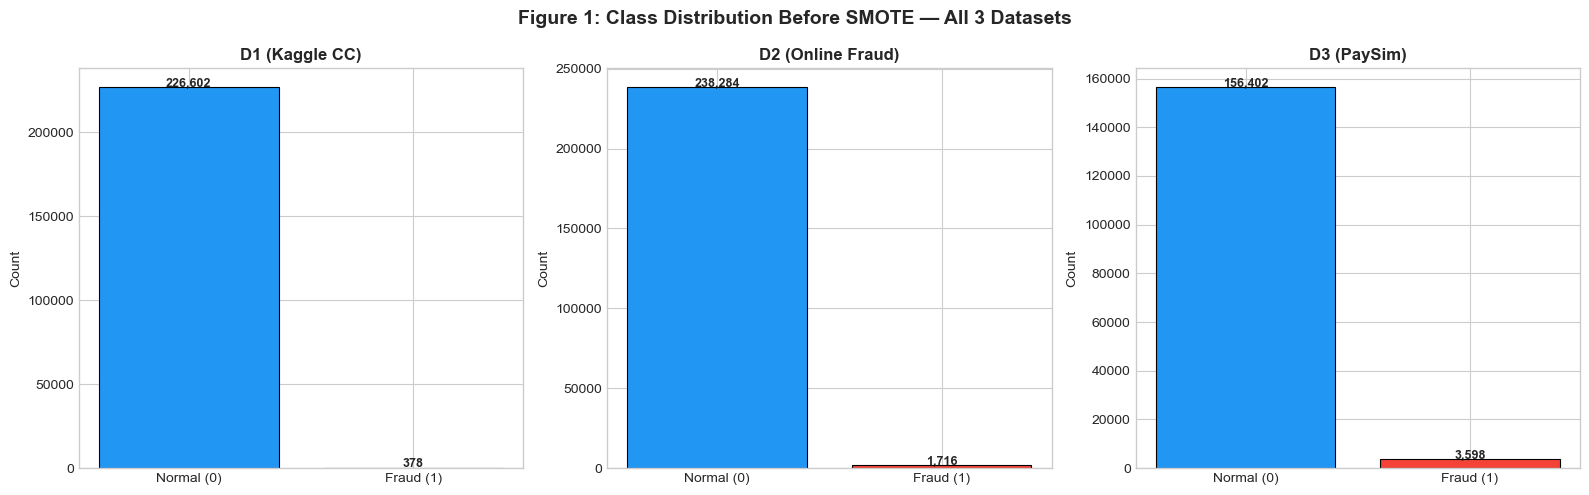

  ✅ fig1_distribution_before_smote.png


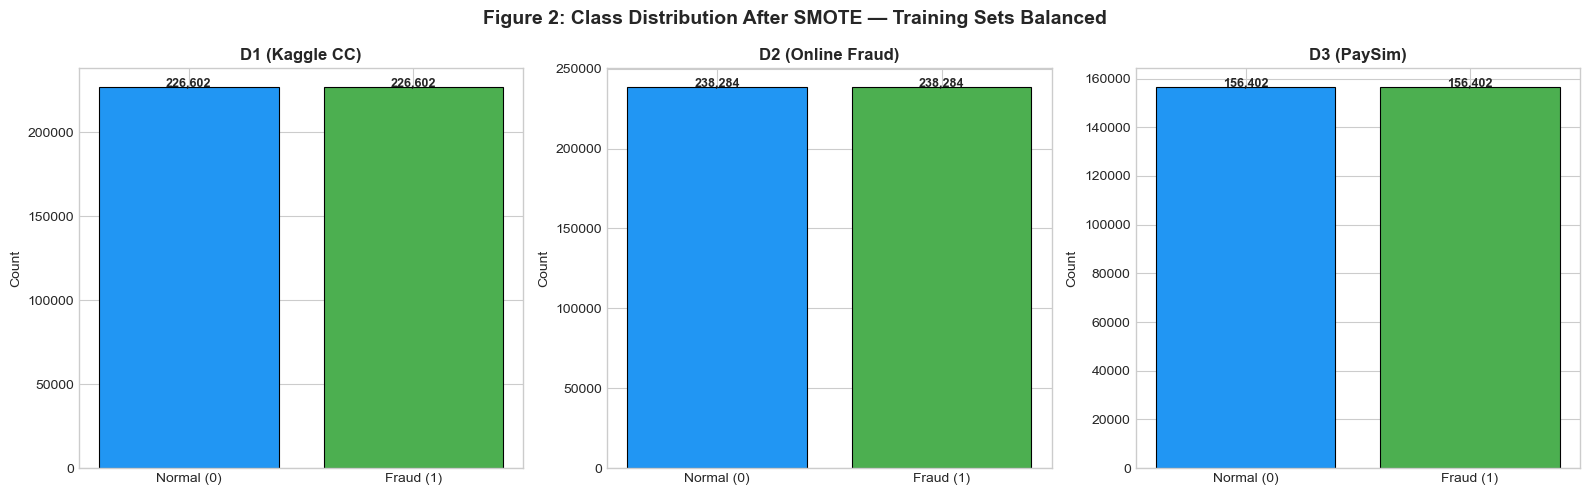

  ✅ fig2_distribution_after_smote.png


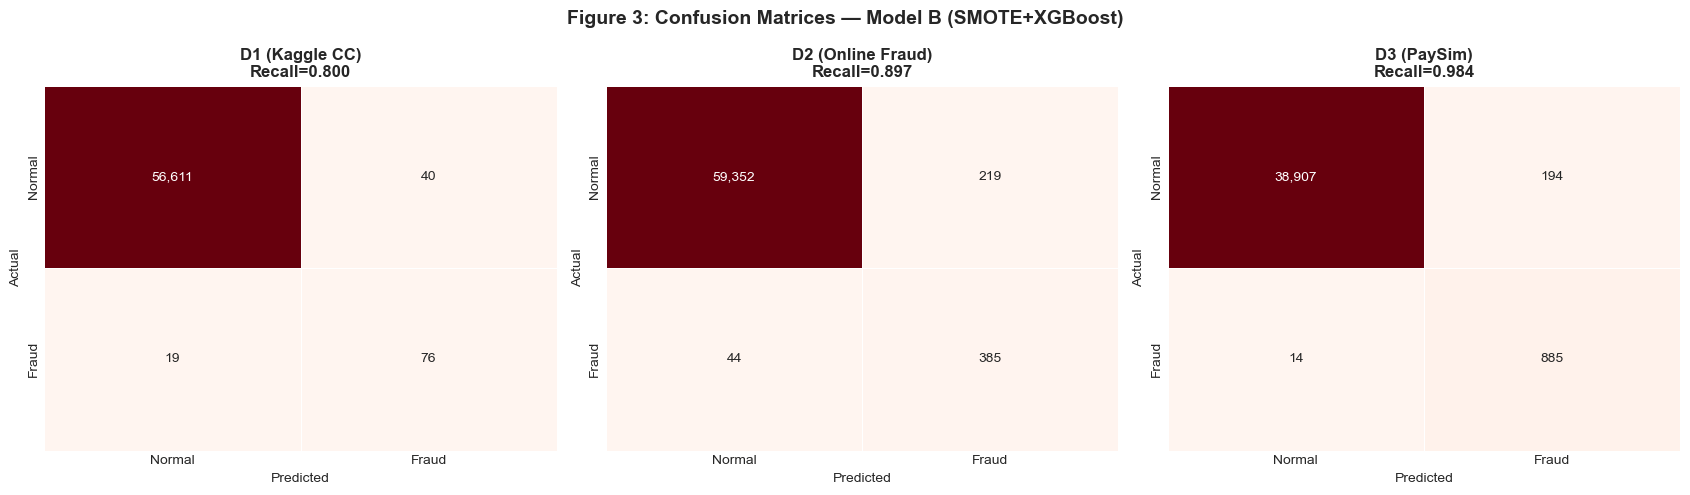

  ✅ fig3_cm_model_B.png


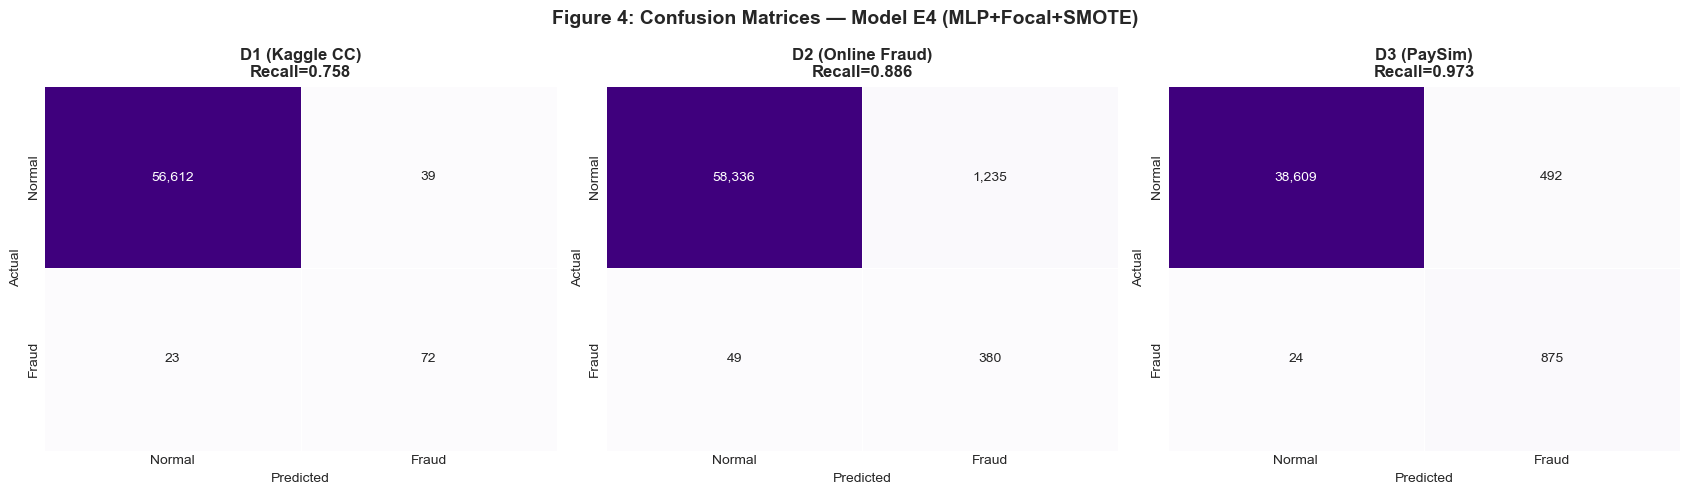

  ✅ fig4_cm_model_E4.png


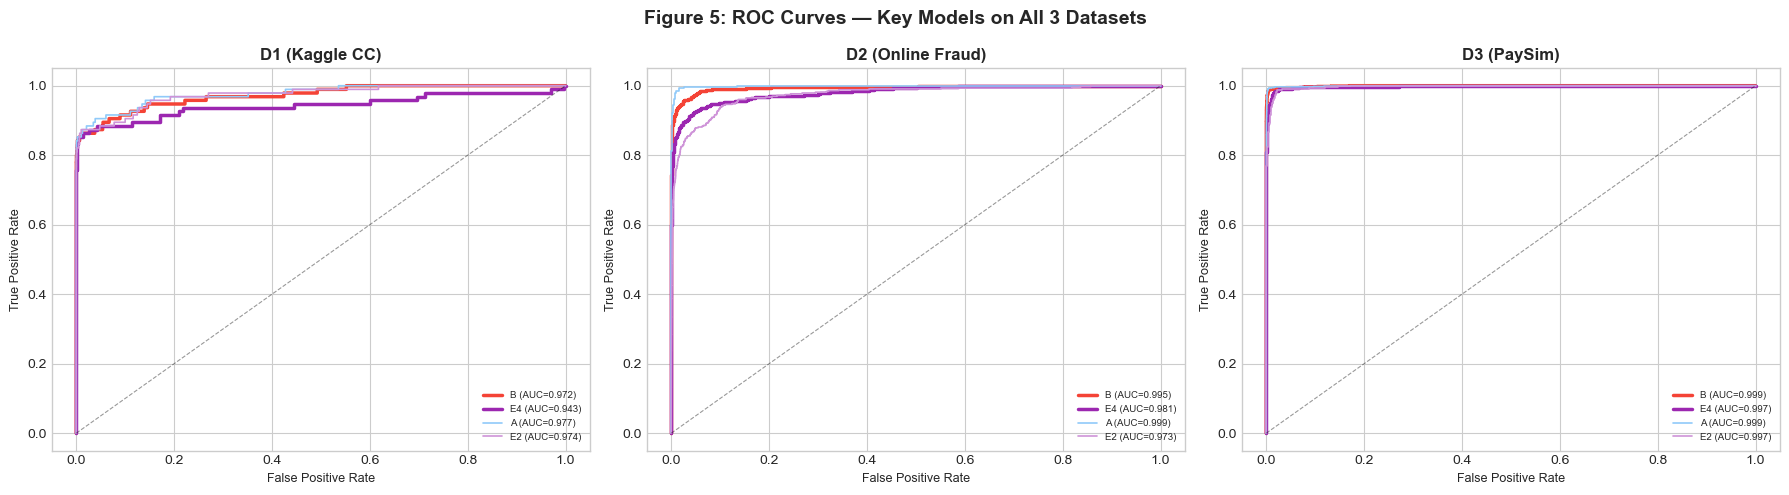

  ✅ fig5_roc_curves.png


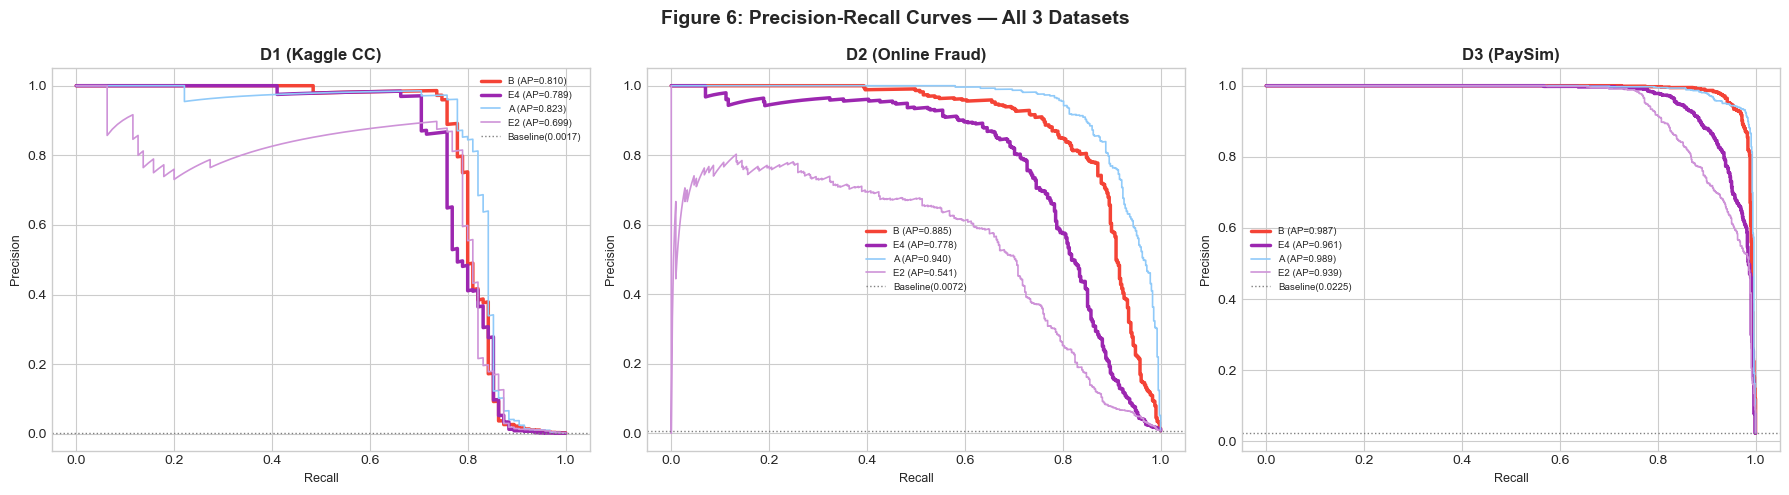

  ✅ fig6_pr_curves.png


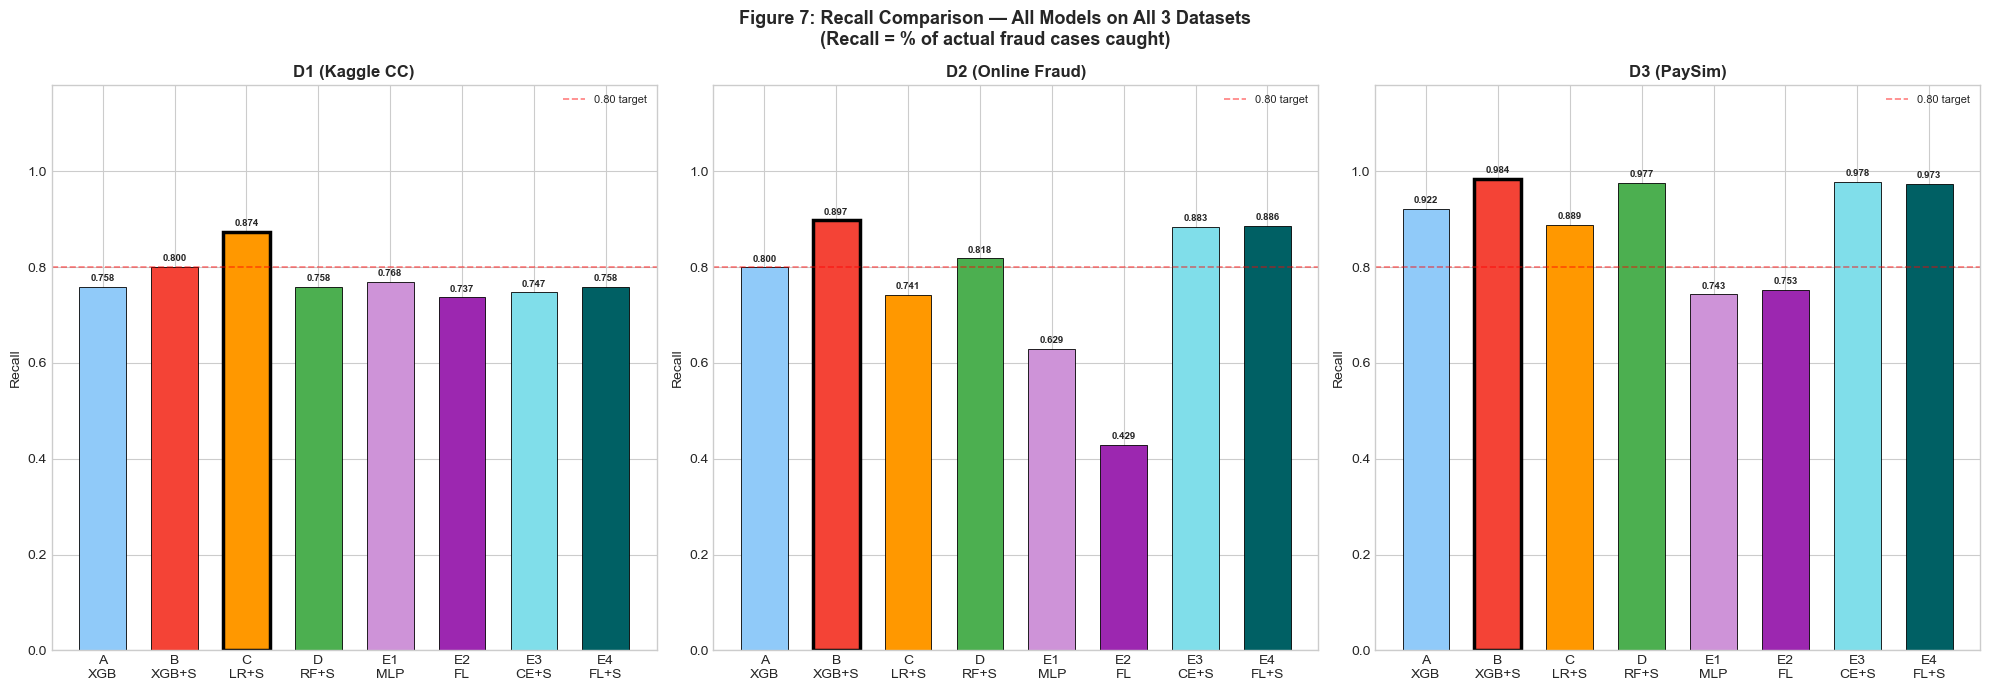

  ✅ fig7_recall_comparison.png


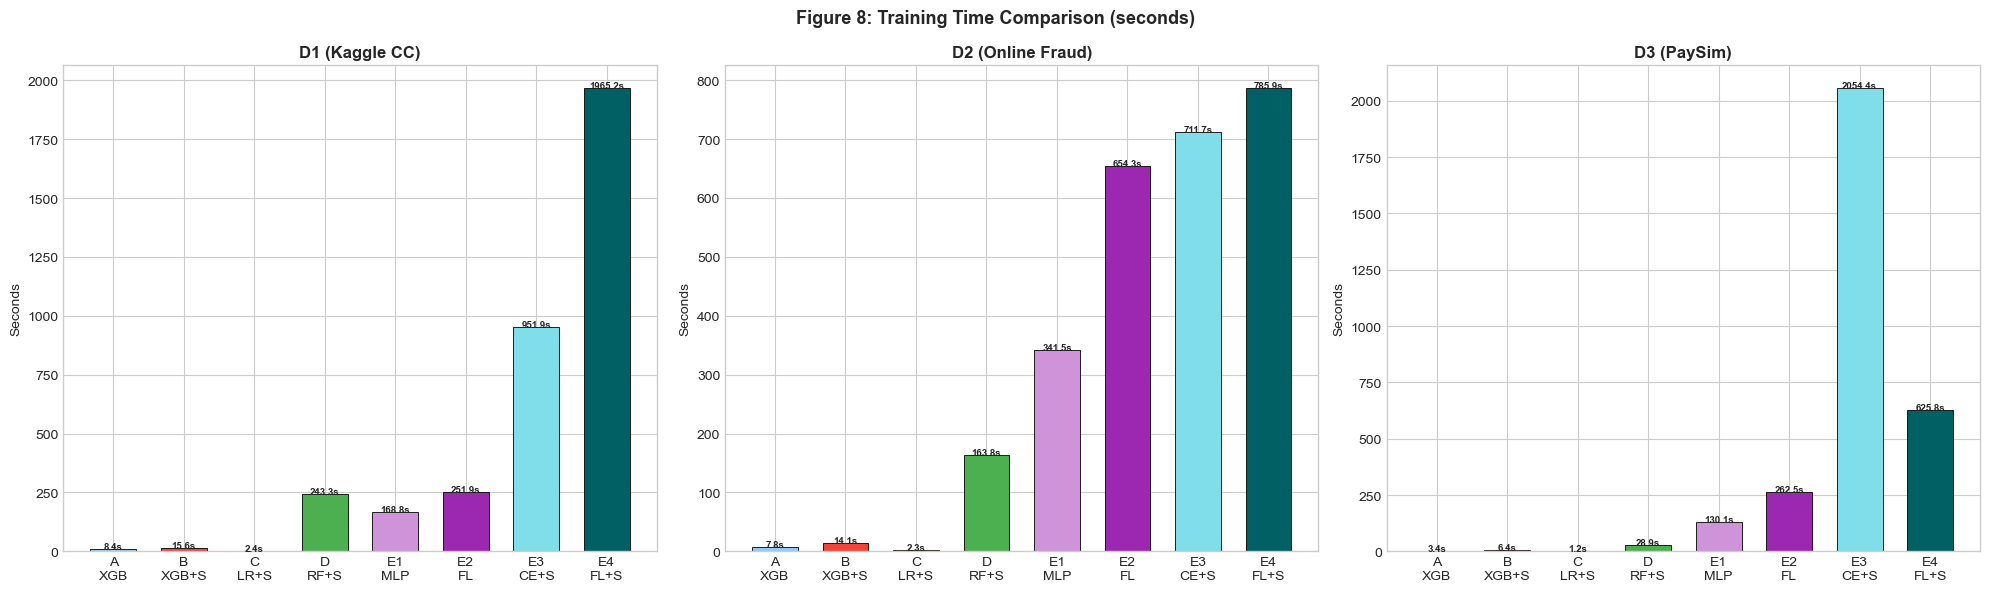

  ✅ fig8_training_time.png


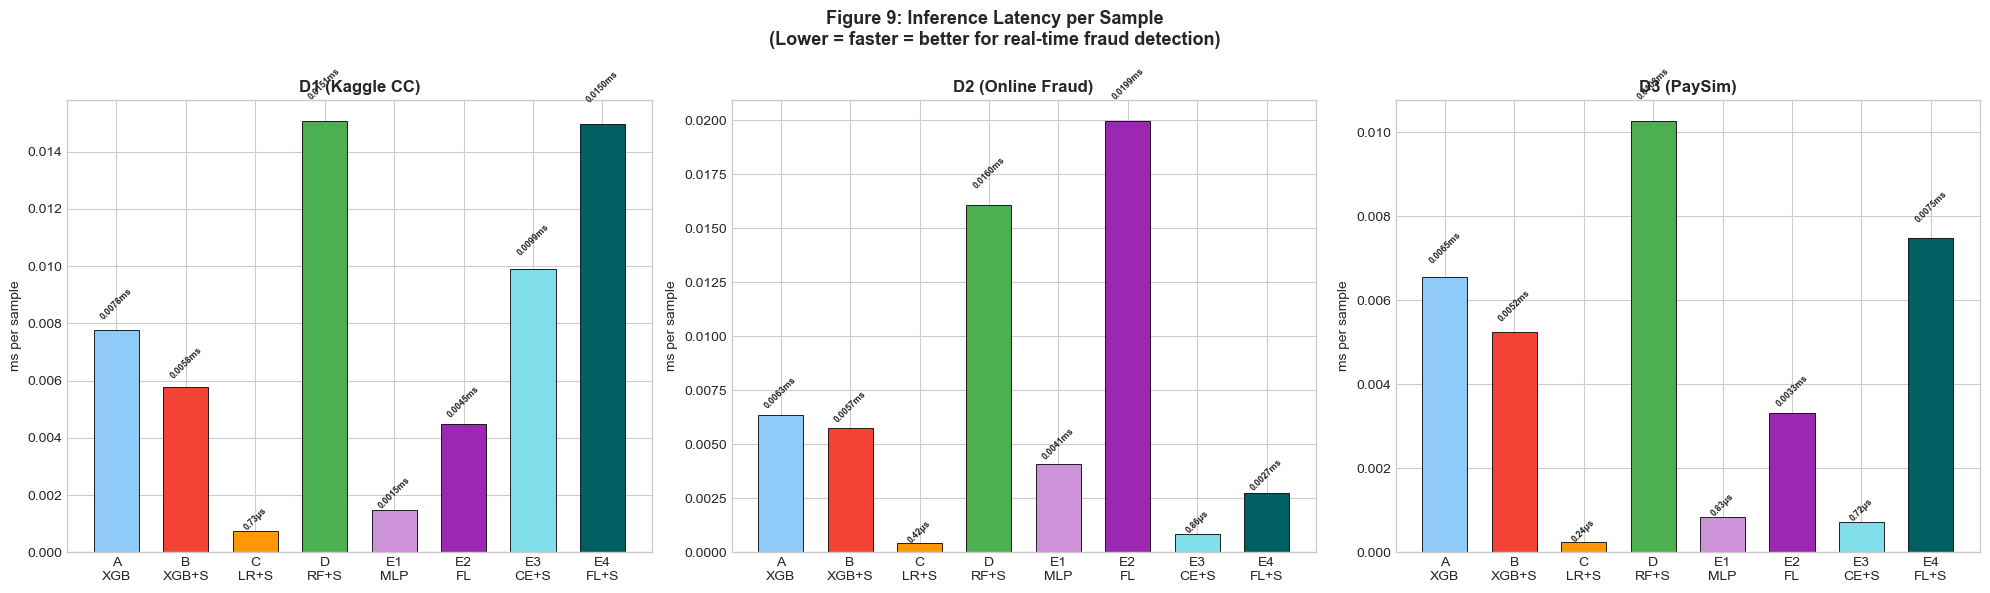

  ✅ fig9_latency.png


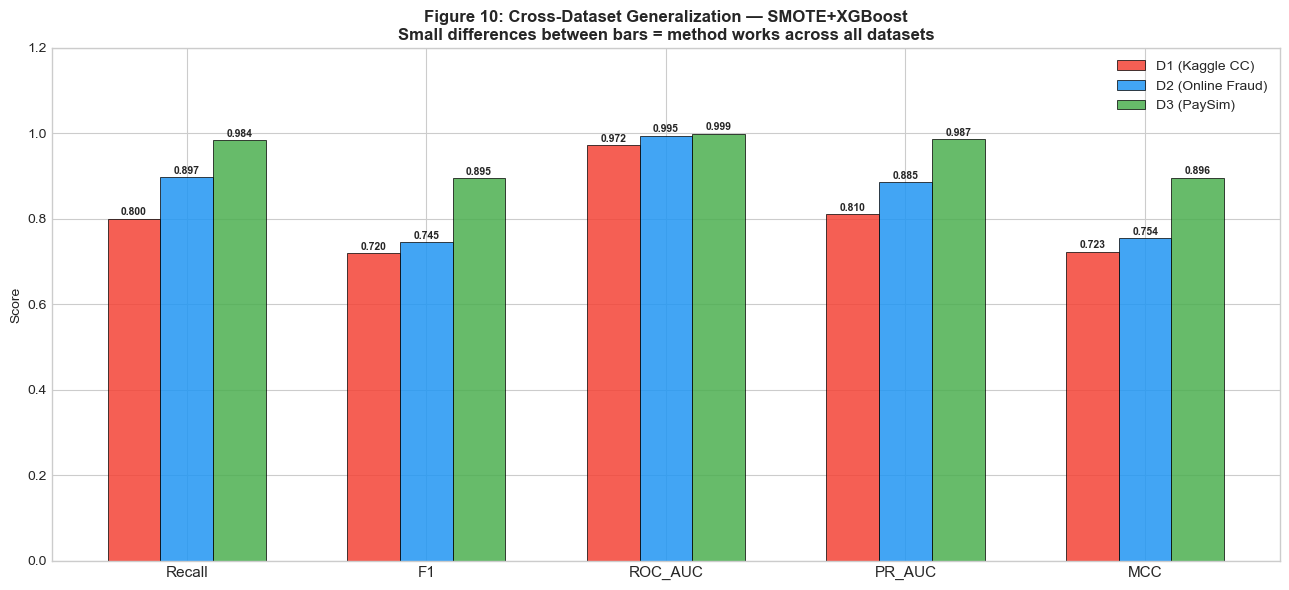

  ✅ fig10_cross_dataset.png


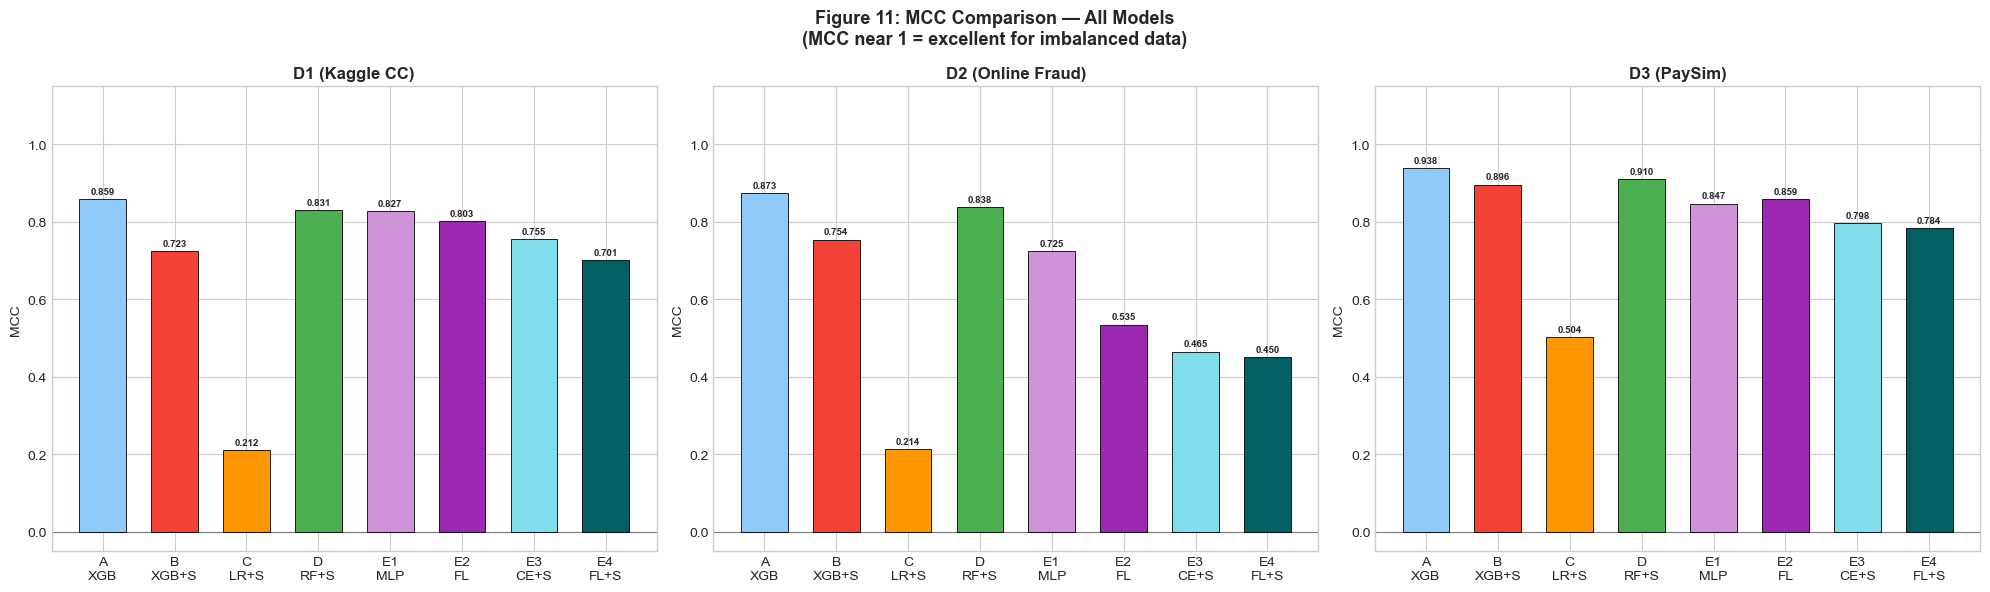

  ✅ fig11_mcc_comparison.png

  Generating SHAP plots...


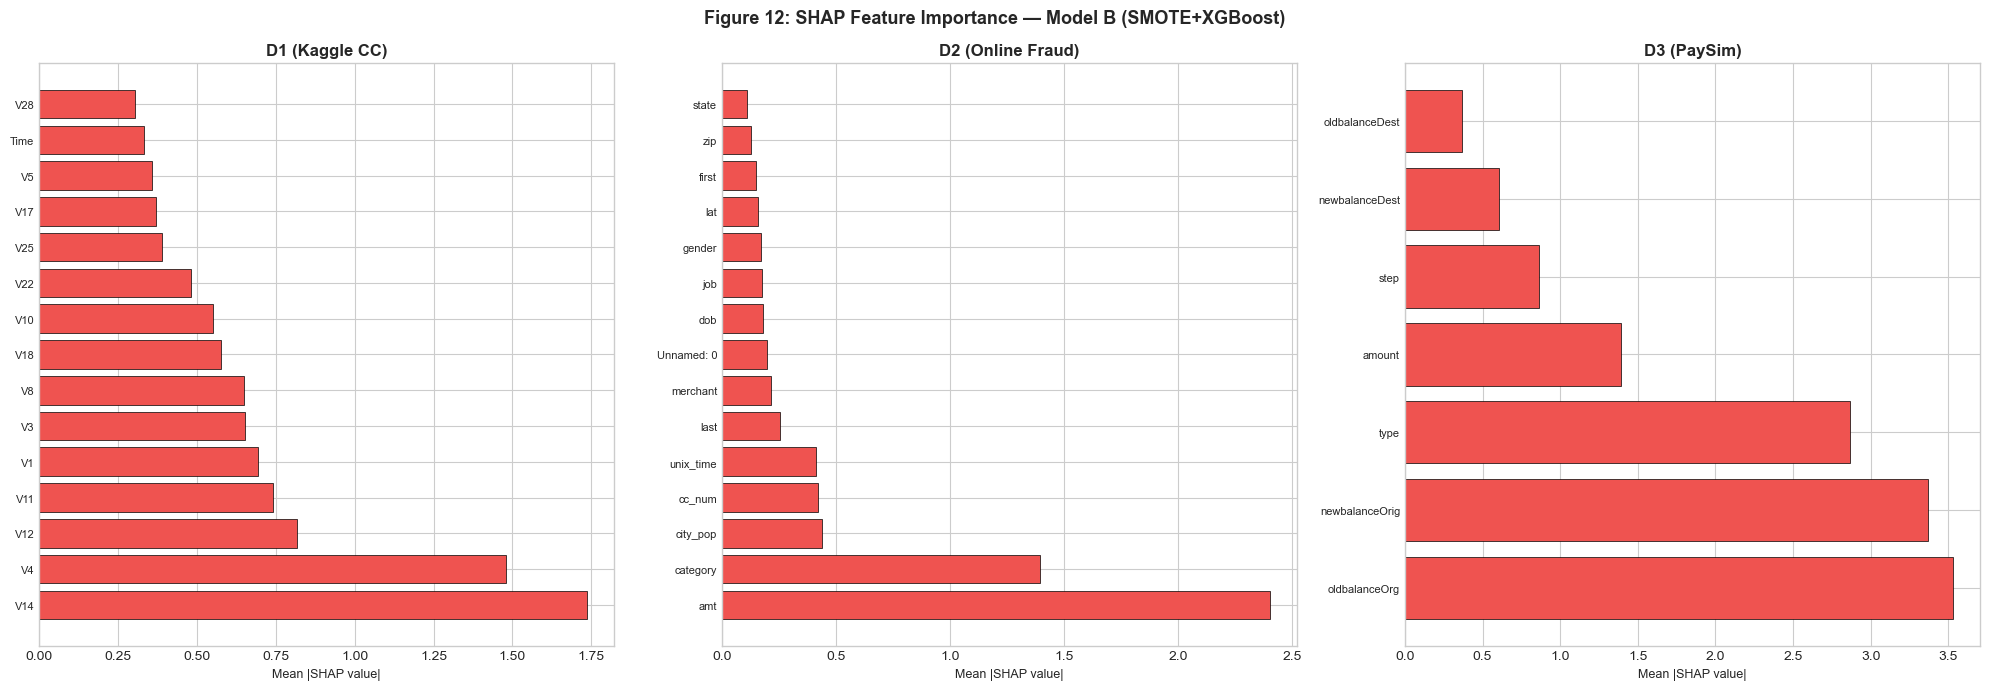

  ✅ fig12_shap_tree.png


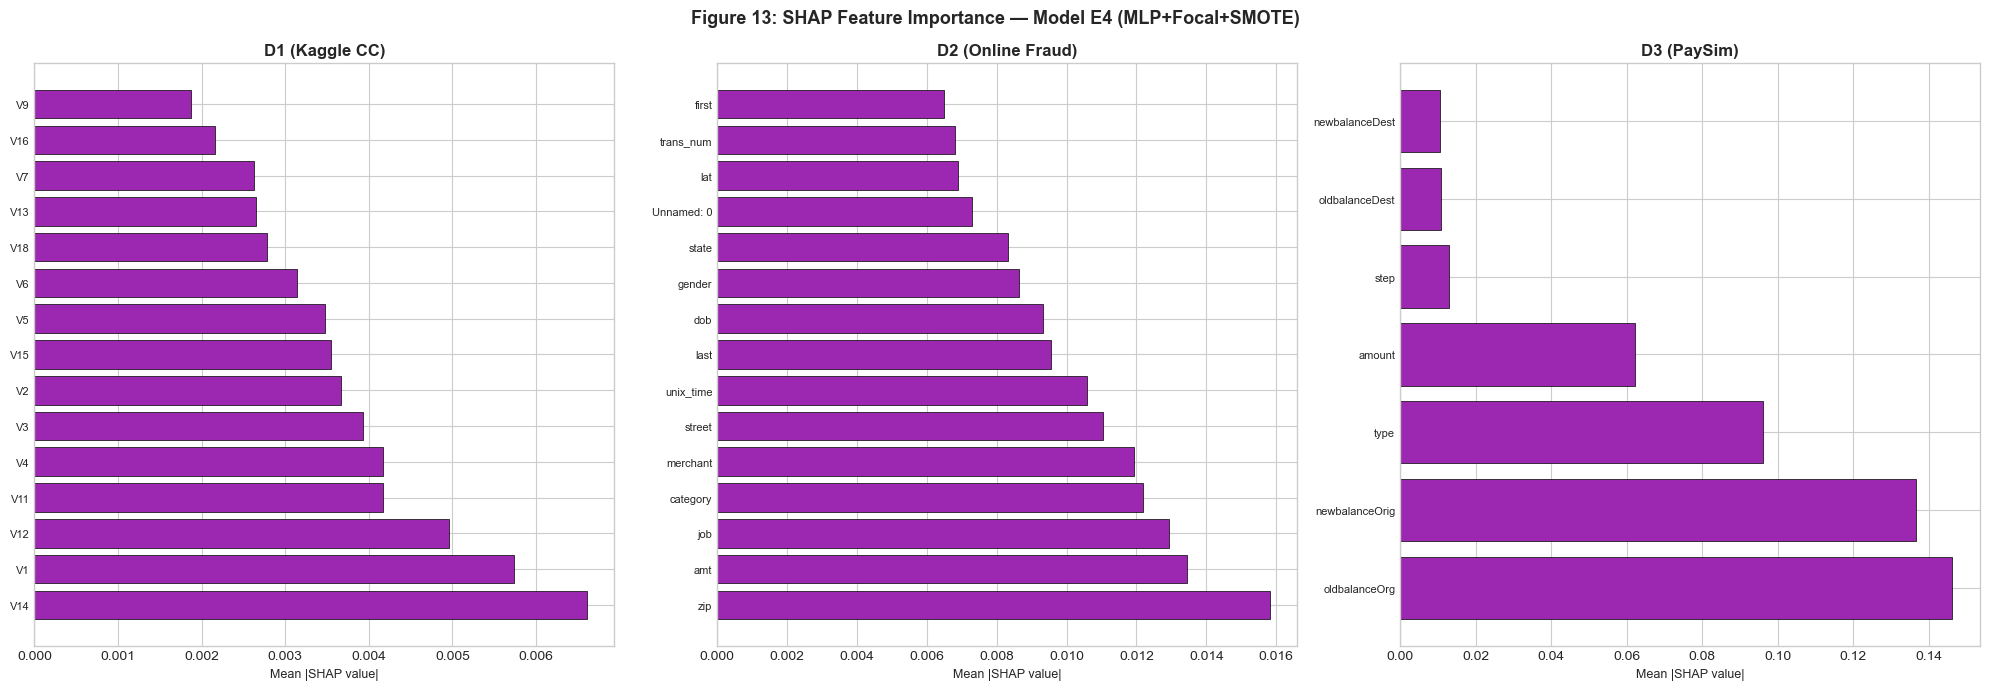

  ✅ fig13_shap_deep.png


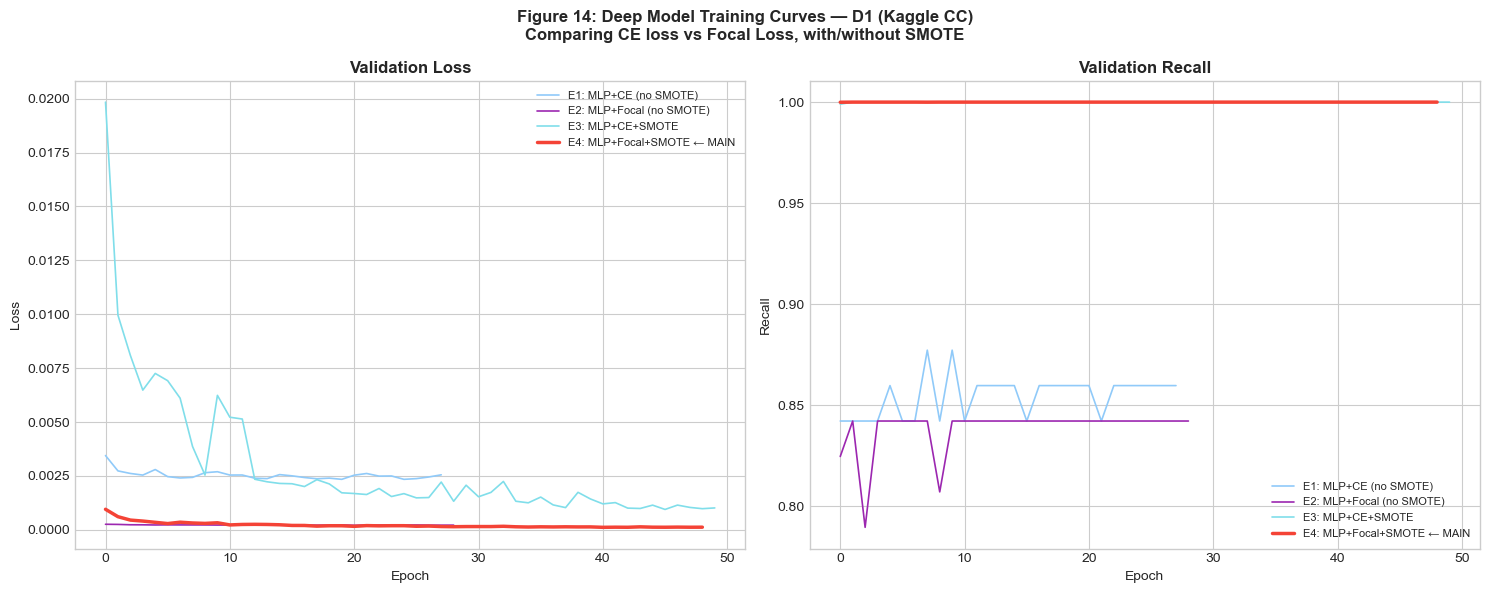

  ✅ fig14_deep_training_curves.png


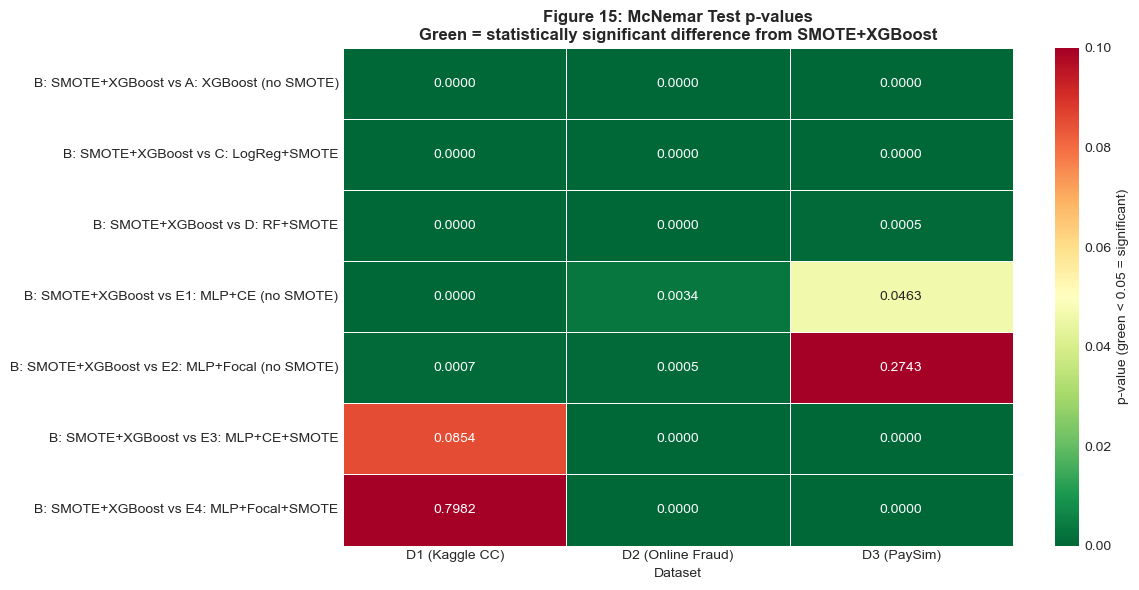

  ✅ fig15_mcnemar_heatmap.png

✅ ALL FIGURES COMPLETE.
👉 Run SECTION 10 next (final summary tables).


In [18]:
# ==============================================================================
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  SECTION 9 — ALL PUBLICATION-QUALITY FIGURES                          ║
# ╚══════════════════════════════════════════════════════════════════════════╝
# What this does:
#   Creates ALL figures needed for your paper and saves them as PNG files.
#
#   Figure list:
#    F1  — Class distribution before SMOTE (3 datasets)
#    F2  — Class distribution after SMOTE
#    F3  — Confusion matrices (Model B on all 3 datasets)
#    F4  — Confusion matrices (Model E4 on all 3 datasets)
#    F5  — ROC curves (B vs E4 on all 3 datasets)
#    F6  — Precision-Recall curves
#    F7  — Recall comparison bar chart (all models × all datasets)
#    F8  — Training time comparison
#    F9  — Inference latency comparison (fixed — no 0.0 ms)
#    F10 — Cross-dataset generalization (Model B)
#    F11 — MCC comparison
#    F12 — SHAP bar chart (Model B, all 3 datasets)
#    F13 — SHAP bar chart (Model E4, all 3 datasets)
#    F14 — Deep model training loss curves (E1-E4, one dataset shown)
#    F15 — McNemar p-value heatmap
# ==============================================================================

print("=" * 60)
print("  SECTION 9 — GENERATING ALL FIGURES")
print("=" * 60)

plt.style.use('seaborn-v0_8-whitegrid')
DPI = 300

DS_NAMES   = [ds['name'] for ds in datasets]
MODEL_KEYS = ['A: XGBoost (no SMOTE)',   'B: SMOTE+XGBoost',
              'C: LogReg+SMOTE',          'D: RF+SMOTE',
              'E1: MLP+CE (no SMOTE)',    'E2: MLP+Focal (no SMOTE)',
              'E3: MLP+CE+SMOTE',         'E4: MLP+Focal+SMOTE']
COLORS_M   = ['#90CAF9','#F44336','#FF9800','#4CAF50',
               '#CE93D8','#9C27B0','#80DEEA','#006064']

def get_r(model_lbl, ds_name):
    for r in all_results:
        if r['Model']==model_lbl and r['Dataset']==ds_name:
            return r
    return None

def label_bar(ax, bars, fmt='{:.3f}', offset=0.01):
    for b in bars:
        h = b.get_height()
        ax.text(b.get_x()+b.get_width()/2., h+offset,
                fmt.format(h), ha='center', va='bottom',
                fontsize=7, fontweight='bold')

# ── F1: Class distribution BEFORE SMOTE ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Figure 1: Class Distribution Before SMOTE — All 3 Datasets',
             fontsize=14, fontweight='bold')
for ax, ds in zip(axes, datasets):
    c = pd.Series(ds['y_train']).value_counts().sort_index()
    bars = ax.bar(['Normal (0)','Fraud (1)'],
                  [c.get(0,0), c.get(1,0)],
                  color=['#2196F3','#F44336'], edgecolor='black', lw=0.8)
    ax.set_title(ds['name'], fontweight='bold')
    ax.set_ylabel('Count')
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2., b.get_height()+200,
                f'{int(b.get_height()):,}', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
fig.savefig(SAVE_PATH+'fig1_distribution_before_smote.png', dpi=DPI, bbox_inches='tight')
plt.show()
print("  ✅ fig1_distribution_before_smote.png")

# ── F2: Class distribution AFTER SMOTE ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Figure 2: Class Distribution After SMOTE — Training Sets Balanced',
             fontsize=14, fontweight='bold')
for ax, ds in zip(axes, datasets):
    c = pd.Series(ds['y_train_sm']).value_counts().sort_index()
    bars = ax.bar(['Normal (0)','Fraud (1)'],
                  [c.get(0,0), c.get(1,0)],
                  color=['#2196F3','#4CAF50'], edgecolor='black', lw=0.8)
    ax.set_title(ds['name'], fontweight='bold')
    ax.set_ylabel('Count')
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2., b.get_height()+200,
                f'{int(b.get_height()):,}', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
fig.savefig(SAVE_PATH+'fig2_distribution_after_smote.png', dpi=DPI, bbox_inches='tight')
plt.show()
print("  ✅ fig2_distribution_after_smote.png")

# ── F3: Confusion matrices Model B ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Figure 3: Confusion Matrices — Model B (SMOTE+XGBoost)',
             fontsize=14, fontweight='bold')
for ax, ds in zip(axes, datasets):
    r = get_r('B: SMOTE+XGBoost', ds['name'])
    if r:
        sns.heatmap(r['cm'], annot=True, fmt=',d', cmap='Reds', ax=ax,
                    cbar=False, linewidths=0.5,
                    xticklabels=['Normal','Fraud'],
                    yticklabels=['Normal','Fraud'])
        rec = r['cm'][1,1]/(r['cm'][1,0]+r['cm'][1,1]) if (r['cm'][1,0]+r['cm'][1,1])>0 else 0
        ax.set_title(f"{ds['name']}\nRecall={rec:.3f}", fontweight='bold')
        ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
fig.savefig(SAVE_PATH+'fig3_cm_model_B.png', dpi=DPI, bbox_inches='tight')
plt.show()
print("  ✅ fig3_cm_model_B.png")

# ── F4: Confusion matrices Model E4 ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Figure 4: Confusion Matrices — Model E4 (MLP+Focal+SMOTE)',
             fontsize=14, fontweight='bold')
for ax, ds in zip(axes, datasets):
    r = get_r('E4: MLP+Focal+SMOTE', ds['name'])
    if r:
        sns.heatmap(r['cm'], annot=True, fmt=',d', cmap='Purples', ax=ax,
                    cbar=False, linewidths=0.5,
                    xticklabels=['Normal','Fraud'],
                    yticklabels=['Normal','Fraud'])
        rec = r['cm'][1,1]/(r['cm'][1,0]+r['cm'][1,1]) if (r['cm'][1,0]+r['cm'][1,1])>0 else 0
        ax.set_title(f"{ds['name']}\nRecall={rec:.3f}", fontweight='bold')
        ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
fig.savefig(SAVE_PATH+'fig4_cm_model_E4.png', dpi=DPI, bbox_inches='tight')
plt.show()
print("  ✅ fig4_cm_model_E4.png")

# ── F5: ROC Curves ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Figure 5: ROC Curves — Key Models on All 3 Datasets',
             fontsize=14, fontweight='bold')
key_models = ['B: SMOTE+XGBoost','E4: MLP+Focal+SMOTE',
              'A: XGBoost (no SMOTE)','E2: MLP+Focal (no SMOTE)']
roc_colors = ['#F44336','#9C27B0','#90CAF9','#CE93D8']
for ax, ds in zip(axes, datasets):
    for m, col in zip(key_models, roc_colors):
        r = get_r(m, ds['name'])
        if r:
            fpr, tpr, _ = roc_curve(ds['y_test'], r['y_prob'])
            lw = 2.5 if 'SMOTE+XGBoost' in m or 'Focal+SMOTE' in m else 1.2
            ax.plot(fpr, tpr, color=col, lw=lw,
                    label=f"{m.split(':')[0]} (AUC={r['ROC_AUC']:.3f})")
    ax.plot([0,1],[0,1],'k--',lw=0.8,alpha=0.4)
    ax.set_xlabel('False Positive Rate', fontsize=9)
    ax.set_ylabel('True Positive Rate', fontsize=9)
    ax.set_title(ds['name'], fontweight='bold')
    ax.legend(fontsize=7, loc='lower right')
plt.tight_layout()
fig.savefig(SAVE_PATH+'fig5_roc_curves.png', dpi=DPI, bbox_inches='tight')
plt.show()
print("  ✅ fig5_roc_curves.png")

# ── F6: PR Curves ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Figure 6: Precision-Recall Curves — All 3 Datasets',
             fontsize=14, fontweight='bold')
for ax, ds in zip(axes, datasets):
    baseline = ds['y_test'].mean()
    for m, col in zip(key_models, roc_colors):
        r = get_r(m, ds['name'])
        if r:
            prec, rec, _ = precision_recall_curve(ds['y_test'], r['y_prob'])
            lw = 2.5 if 'SMOTE+XGBoost' in m or 'Focal+SMOTE' in m else 1.2
            ax.plot(rec, prec, color=col, lw=lw,
                    label=f"{m.split(':')[0]} (AP={r['PR_AUC']:.3f})")
    ax.axhline(y=baseline, color='gray', ls=':', lw=1, label=f'Baseline({baseline:.4f})')
    ax.set_xlabel('Recall', fontsize=9); ax.set_ylabel('Precision', fontsize=9)
    ax.set_title(ds['name'], fontweight='bold')
    ax.legend(fontsize=7)
plt.tight_layout()
fig.savefig(SAVE_PATH+'fig6_pr_curves.png', dpi=DPI, bbox_inches='tight')
plt.show()
print("  ✅ fig6_pr_curves.png")

# ── F7: Recall comparison (all models × all datasets) ────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Figure 7: Recall Comparison — All Models on All 3 Datasets\n'
             '(Recall = % of actual fraud cases caught)',
             fontsize=13, fontweight='bold')
short_labels = ['A\nXGB','B\nXGB+S','C\nLR+S','D\nRF+S',
                'E1\nMLP','E2\nFL','E3\nCE+S','E4\nFL+S']
for ax, ds in zip(axes, datasets):
    recalls = [get_r(m, ds['name'])['Recall'] if get_r(m,ds['name']) else 0
               for m in MODEL_KEYS]
    bars = ax.bar(short_labels, recalls, color=COLORS_M,
                  edgecolor='black', lw=0.6, width=0.65)
    best_i = recalls.index(max(recalls))
    bars[best_i].set_linewidth(2.5)
    label_bar(ax, bars, offset=0.008)
    ax.set_ylim(0, 1.18)
    ax.set_title(ds['name'], fontweight='bold')
    ax.set_ylabel('Recall')
    ax.axhline(y=0.8, color='red', ls='--', lw=1.2, alpha=0.5, label='0.80 target')
    ax.legend(fontsize=8)
plt.tight_layout()
fig.savefig(SAVE_PATH+'fig7_recall_comparison.png', dpi=DPI, bbox_inches='tight')
plt.show()
print("  ✅ fig7_recall_comparison.png")

# ── F8: Training time ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Figure 8: Training Time Comparison (seconds)',
             fontsize=13, fontweight='bold')
time_keys  = ['time_A','time_B','time_C','time_D',
              'time_E1','time_E2','time_E3','time_E4']
for ax, ds in zip(axes, datasets):
    times = [ds.get(k, 0) for k in time_keys]
    bars  = ax.bar(short_labels, times, color=COLORS_M,
                   edgecolor='black', lw=0.6, width=0.65)
    for b, v in zip(bars, times):
        ax.text(b.get_x()+b.get_width()/2., b.get_height()+0.3,
                f'{v:.1f}s', ha='center', fontsize=7, fontweight='bold')
    ax.set_title(ds['name'], fontweight='bold')
    ax.set_ylabel('Seconds')
plt.tight_layout()
fig.savefig(SAVE_PATH+'fig8_training_time.png', dpi=DPI, bbox_inches='tight')
plt.show()
print("  ✅ fig8_training_time.png")

# ── F9: Inference latency (FIXED — no 0.0 ms) ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Figure 9: Inference Latency per Sample\n'
             '(Lower = faster = better for real-time fraud detection)',
             fontsize=13, fontweight='bold')
for ax, ds in zip(axes, datasets):
    lats  = [get_r(m, ds['name'])['Latency_ms'] if get_r(m,ds['name']) else 0
             for m in MODEL_KEYS]
    bars  = ax.bar(short_labels, lats, color=COLORS_M,
                   edgecolor='black', lw=0.6, width=0.65)
    for b, v in zip(bars, lats):
        if v < 0.001:
            label = f'{v*1000:.2f}μs'
        elif v < 1:
            label = f'{v:.4f}ms'
        else:
            label = f'{v:.2f}ms'
        ax.text(b.get_x()+b.get_width()/2., b.get_height()*1.05,
                label, ha='center', fontsize=6.5, fontweight='bold', rotation=45)
    ax.set_title(ds['name'], fontweight='bold')
    ax.set_ylabel('ms per sample')
plt.tight_layout()
fig.savefig(SAVE_PATH+'fig9_latency.png', dpi=DPI, bbox_inches='tight')
plt.show()
print("  ✅ fig9_latency.png")

# ── F10: Cross-dataset generalization (Model B) ────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))
ax.set_title('Figure 10: Cross-Dataset Generalization — SMOTE+XGBoost\n'
             'Small differences between bars = method works across all datasets',
             fontsize=12, fontweight='bold')
gen_metrics = ['Recall','F1','ROC_AUC','PR_AUC','MCC']
x = np.arange(len(gen_metrics))
w = 0.22
colors_ds = ['#F44336','#2196F3','#4CAF50']
for j, (ds, col) in enumerate(zip(datasets, colors_ds)):
    vals = [get_r('B: SMOTE+XGBoost', ds['name'])[m] for m in gen_metrics]
    bars = ax.bar(x + (j-1)*w, vals, w, label=ds['name'],
                  color=col, alpha=0.85, edgecolor='black', lw=0.6)
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2., b.get_height()+0.008,
                f'{v:.3f}', ha='center', fontsize=7.5, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(gen_metrics, fontsize=11)
ax.set_ylim(0, 1.2); ax.set_ylabel('Score')
ax.legend(fontsize=10)
plt.tight_layout()
fig.savefig(SAVE_PATH+'fig10_cross_dataset.png', dpi=DPI, bbox_inches='tight')
plt.show()
print("  ✅ fig10_cross_dataset.png")

# ── F11: MCC comparison ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Figure 11: MCC Comparison — All Models\n'
             '(MCC near 1 = excellent for imbalanced data)',
             fontsize=13, fontweight='bold')
for ax, ds in zip(axes, datasets):
    mccs  = [get_r(m, ds['name'])['MCC'] if get_r(m,ds['name']) else 0
             for m in MODEL_KEYS]
    bars  = ax.bar(short_labels, mccs, color=COLORS_M,
                   edgecolor='black', lw=0.6, width=0.65)
    label_bar(ax, bars, offset=0.008)
    ax.set_ylim(min(0, min(mccs))-0.05, 1.15)
    ax.set_title(ds['name'], fontweight='bold')
    ax.set_ylabel('MCC')
    ax.axhline(y=0, color='black', lw=0.8, alpha=0.4)
plt.tight_layout()
fig.savefig(SAVE_PATH+'fig11_mcc_comparison.png', dpi=DPI, bbox_inches='tight')
plt.show()
print("  ✅ fig11_mcc_comparison.png")

# ── F12: SHAP bar chart — Model B ────────────────────────────────────────
print("\n  Generating SHAP plots...")
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Figure 12: SHAP Feature Importance — Model B (SMOTE+XGBoost)',
             fontsize=13, fontweight='bold')
for ax, ds in zip(axes, datasets):
    try:
        sv, Xs = ds['shap_tree']
        
        # Handle SHAP value format
        if isinstance(sv, list):
            sv = sv[0]  # For binary classification
        
        # Ensure sv is 2D array
        sv_arr = np.array(sv)
        if sv_arr.ndim == 1:
            sv_arr = sv_arr.reshape(1, -1)
        
        # Calculate mean absolute SHAP values
        shap_mean = np.abs(sv_arr).mean(axis=0)
        
        # Ensure 1D
        if shap_mean.ndim > 1:
            shap_mean = shap_mean.flatten()
        
        # Get top features
        n_features = min(15, len(shap_mean))
        top_idx = np.argsort(shap_mean)[-n_features:]
        top_idx = top_idx.flatten() if hasattr(top_idx, 'flatten') else top_idx
        
        # Get feature names
        if hasattr(Xs, 'columns'):
            feature_names = Xs.columns
        else:
            feature_names = [f'Feature_{i}' for i in range(len(shap_mean))]
        
        top_feats = [feature_names[i] for i in top_idx]
        top_vals = shap_mean[top_idx]
        
        # Plot
        ax.barh(range(len(top_feats)), top_vals[::-1],
                color='#EF5350', edgecolor='black', lw=0.5)
        ax.set_yticks(range(len(top_feats)))
        ax.set_yticklabels(list(reversed(top_feats)), fontsize=8)
        ax.set_xlabel('Mean |SHAP value|', fontsize=9)
        ax.set_title(ds['name'], fontweight='bold')
        
    except Exception as e:
        print(f"  ⚠️ Error plotting SHAP for {ds['name']}: {e}")
        ax.text(0.5, 0.5, f'SHAP data not available\nfor {ds["name"]}', 
                ha='center', va='center', transform=ax.transAxes)
plt.tight_layout()
fig.savefig(SAVE_PATH+'fig12_shap_tree.png', dpi=DPI, bbox_inches='tight')
plt.show()
print("  ✅ fig12_shap_tree.png")

# ── F13: SHAP bar chart — Model E4 ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Figure 13: SHAP Feature Importance — Model E4 (MLP+Focal+SMOTE)',
             fontsize=13, fontweight='bold')
for ax, ds in zip(axes, datasets):
    try:
        sv, Xs = ds['shap_deep']
        
        # Handle SHAP value format
        if isinstance(sv, list):
            sv = sv[0]  # For binary classification
        
        # Ensure sv is 2D array
        sv_arr = np.array(sv)
        if sv_arr.ndim == 1:
            sv_arr = sv_arr.reshape(1, -1)
        
        # Calculate mean absolute SHAP values
        shap_mean = np.abs(sv_arr).mean(axis=0)
        
        # Ensure 1D
        if shap_mean.ndim > 1:
            shap_mean = shap_mean.flatten()
        
        # Get top features
        n_features = min(15, len(shap_mean))
        top_idx = np.argsort(shap_mean)[-n_features:]
        top_idx = top_idx.flatten() if hasattr(top_idx, 'flatten') else top_idx
        
        # Get feature names
        if hasattr(Xs, 'columns'):
            feature_names = Xs.columns
        else:
            feature_names = [f'Feature_{i}' for i in range(len(shap_mean))]
        
        top_feats = [feature_names[i] for i in top_idx]
        top_vals = shap_mean[top_idx]
        
        # Plot
        ax.barh(range(len(top_feats)), top_vals[::-1],
                color='#9C27B0', edgecolor='black', lw=0.5)
        ax.set_yticks(range(len(top_feats)))
        ax.set_yticklabels(list(reversed(top_feats)), fontsize=8)
        ax.set_xlabel('Mean |SHAP value|', fontsize=9)
        ax.set_title(ds['name'], fontweight='bold')
        
    except Exception as e:
        print(f"  ⚠️ Error plotting SHAP for {ds['name']}: {e}")
        ax.text(0.5, 0.5, f'SHAP data not available\nfor {ds["name"]}', 
                ha='center', va='center', transform=ax.transAxes)
plt.tight_layout()
fig.savefig(SAVE_PATH+'fig13_shap_deep.png', dpi=DPI, bbox_inches='tight')
plt.show()
print("  ✅ fig13_shap_deep.png")

# ── F14: Deep model training curves (Dataset 1 shown) ────────────────────
if len(datasets) > 0:
    ds0 = datasets[0]
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle('Figure 14: Deep Model Training Curves — D1 (Kaggle CC)\n'
                 'Comparing CE loss vs Focal Loss, with/without SMOTE',
                 fontsize=12, fontweight='bold')

    for hist_key, label, color in [
        ('hist_E1','E1: MLP+CE (no SMOTE)','#90CAF9'),
        ('hist_E2','E2: MLP+Focal (no SMOTE)','#9C27B0'),
        ('hist_E3','E3: MLP+CE+SMOTE','#80DEEA'),
        ('hist_E4','E4: MLP+Focal+SMOTE ← MAIN','#F44336'),
    ]:
        if hist_key in ds0:
            h = ds0[hist_key]
            axes[0].plot(h['val_loss'],   label=label, color=color,
                         lw=2.5 if 'MAIN' in label else 1.2)
            axes[1].plot(h['val_recall'], label=label, color=color,
                         lw=2.5 if 'MAIN' in label else 1.2)

    axes[0].set_title('Validation Loss', fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(fontsize=8)

    axes[1].set_title('Validation Recall', fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Recall')
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    fig.savefig(SAVE_PATH+'fig14_deep_training_curves.png', dpi=DPI, bbox_inches='tight')
    plt.show()
    print("  ✅ fig14_deep_training_curves.png")
else:
    print("  ⚠️ No datasets available for training curves")

# ── F15: McNemar p-value heatmap ──────────────────────────────────────────
if 'mcnemar_df' in locals() and len(mcnemar_df) > 0:
    try:
        pivot = mcnemar_df.pivot(index='Comparison', columns='Dataset', values='p_value')
        fig, ax = plt.subplots(figsize=(12, max(6, len(pivot)*0.6)))
        sns.heatmap(pivot, annot=True, fmt='.4f', cmap='RdYlGn_r',
                    ax=ax, linewidths=0.5, vmin=0, vmax=0.1,
                    cbar_kws={'label': 'p-value (green < 0.05 = significant)'})
        ax.set_title('Figure 15: McNemar Test p-values\n'
                     'Green = statistically significant difference from SMOTE+XGBoost',
                     fontsize=12, fontweight='bold')
        ax.set_xlabel('Dataset'); ax.set_ylabel('')
        plt.tight_layout()
        fig.savefig(SAVE_PATH+'fig15_mcnemar_heatmap.png', dpi=DPI, bbox_inches='tight')
        plt.show()
        print("  ✅ fig15_mcnemar_heatmap.png")
    except Exception as e:
        print(f"  ⚠️ Could not create McNemar heatmap: {e}")
else:
    print("  ⚠️ McNemar data not available, skipping Figure 15")

print("\n✅ ALL FIGURES COMPLETE.")
print("👉 Run SECTION 10 next (final summary tables).")

In [19]:
# ==============================================================================
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  SECTION 10 — FINAL SUMMARY TABLES                                    ║
# ╚══════════════════════════════════════════════════════════════════════════╝
# What this does:
#   Builds and prints the big summary tables for your paper:
#     Table 1 — Dataset statistics (sizes, fraud rates)
#     Table 2 — Full performance results (all models × all datasets)
#     Table 3 — Literature comparison (your work vs 6 papers)
#   All tables saved as CSV files.
# ==============================================================================

print("=" * 60)
print("  SECTION 10 — FINAL SUMMARY TABLES")
print("=" * 60)

# ── Table 1: Dataset statistics ───────────────────────────────────────────
print("\n── Table 1: Dataset Summary ──")
t1_rows = []
for ds, raw_y in zip(datasets,
                     [y1, y2, y3]):
    n      = len(raw_y)
    fraud  = raw_y.sum()
    t1_rows.append({
        'Dataset'        : ds['name'],
        'Total rows'     : f"{n:,}",
        'Fraud cases'    : f"{fraud:,}",
        'Fraud rate'     : f"{fraud/n*100:.4f}%",
        'Imbalance ratio': f"{int((n-fraud)/fraud)}:1",
        'Test fraud'     : f"{ds['y_test'].sum():,}",
    })
t1 = pd.DataFrame(t1_rows)
print(t1.to_string(index=False))
t1.to_csv(SAVE_PATH+'table1_dataset_summary.csv', index=False)

# ── Table 2: Full performance results ─────────────────────────────────────
print("\n── Table 2: Full Performance Results ──")
t2_rows = []
for r in all_results:
    t2_rows.append({
        'Dataset'  : r['Dataset'],
        'Model'    : r['Model'],
        'Recall'   : f"{r['Recall']:.4f}",
        'Precision': f"{r['Precision']:.4f}",
        'F1'       : f"{r['F1']:.4f}",
        'ROC-AUC'  : f"{r['ROC_AUC']:.4f}",
        'PR-AUC'   : f"{r['PR_AUC']:.4f}",
        'MCC'      : f"{r['MCC']:.4f}",
        'Train(s)' : f"{r['TrainTime_s']:.1f}",
        'Latency'  : r['Latency_display'],
    })
t2 = pd.DataFrame(t2_rows)
print(t2.to_string(index=False))
t2.to_csv(SAVE_PATH+'table2_full_results.csv', index=False)

# ── Table 3: Literature comparison ────────────────────────────────────────
print("\n── Table 3: Literature Comparison ──")
your_b_d1 = get_r('B: SMOTE+XGBoost', datasets[0]['name'])
your_b_d2 = get_r('B: SMOTE+XGBoost', datasets[1]['name'])
your_b_d3 = get_r('B: SMOTE+XGBoost', datasets[2]['name'])
your_e4_d1= get_r('E4: MLP+Focal+SMOTE', datasets[0]['name'])

lit = pd.DataFrame({
    'Study'        : ['Albalawi & Dardouri (2025)',
                      'Rahmadani et al. (2025)',
                      'Patel et al. (2025)',
                      'Asnawi et al. (2025)',
                      'Du et al. (2024)',
                      'Anitha et al. (2025)',
                      '★ OUR WORK (Model B: SMOTE+XGBoost)',
                      '★ OUR WORK (Model E4: MLP+Focal+SMOTE)'],
    'Method'       : ['RF+DL+Focal Loss',
                      'XGBoost+SMOTE+GridSearchCV',
                      'XGBoost+SMOTE-ENN',
                      'XGBoost+SMOTE',
                      'AE+XGBoost+SMOTE+CGAN',
                      'XGBoost+SMOTE-Tomek',
                      'SMOTE+XGBoost (simple)',
                      'MLP+Focal Loss+SMOTE'],
    'Datasets'     : [2,1,1,1,1,1,3,3],
    'Recall (D1)'  : ['100%*','85%','89%','82%','89.3%','94.1%',
                      f"{your_b_d1['Recall']*100:.1f}%" if your_b_d1 else 'N/A',
                      f"{your_e4_d1['Recall']*100:.1f}%" if your_e4_d1 else 'N/A'],
    'Stat. Test'   : ['No','No','No','No','No','No','McNemar','McNemar'],
    'MCC reported' : ['No','No','No','No','Yes (0.884)','No',
                      f"{your_b_d1['MCC']:.3f}" if your_b_d1 else 'N/A',
                      f"{your_e4_d1['MCC']:.3f}" if your_e4_d1 else 'N/A'],
    'SHAP'         : ['No','No','No','No','No','No','Yes','Yes'],
    'Train time'   : ['NR','NR','NR','NR','NR','~35ms/sample',
                      f"{your_b_d1['TrainTime_s']:.0f}s" if your_b_d1 else 'N/A',
                      f"{your_e4_d1['TrainTime_s']:.0f}s" if your_e4_d1 else 'N/A'],
})
print(lit.to_string(index=False))
lit.to_csv(SAVE_PATH+'table3_literature_comparison.csv', index=False)

# ── FINAL PRINT ───────────────────────────────────────────────────────────
print("\n" + "="*65)
print("  ★  COMPLETE RESEARCH SUMMARY  ★")
print("="*65)
print(f"\n  {'Model':<30} {'D1 Recall':>10} {'D2 Recall':>10} {'D3 Recall':>10}")
print(f"  {'-'*60}")
for m in ['B: SMOTE+XGBoost', 'E4: MLP+Focal+SMOTE']:
    recalls = [get_r(m,ds['name'])['Recall'] if get_r(m,ds['name']) else 0
               for ds in datasets]
    print(f"  {m:<30} {recalls[0]:>10.3f} {recalls[1]:>10.3f} {recalls[2]:>10.3f}")

print(f"\n  Files saved to: {SAVE_PATH}")
print("""
  Figures:
    fig1_distribution_before_smote.png    fig9_latency.png
    fig2_distribution_after_smote.png     fig10_cross_dataset.png
    fig3_cm_model_B.png                   fig11_mcc_comparison.png
    fig4_cm_model_E4.png                  fig12_shap_tree.png
    fig5_roc_curves.png                   fig13_shap_deep.png
    fig6_pr_curves.png                    fig14_deep_training_curves.png
    fig7_recall_comparison.png            fig15_mcnemar_heatmap.png
    fig8_training_time.png

  Tables:
    results_table.csv                 table1_dataset_summary.csv
    mcnemar_results.csv               table2_full_results.csv
    table3_literature_comparison.csv
""")
print("🎉 CODE COMPLETE! All figures and tables ready for your paper.")


  SECTION 10 — FINAL SUMMARY TABLES

── Table 1: Dataset Summary ──
          Dataset Total rows Fraud cases Fraud rate Imbalance ratio Test fraud
   D1 (Kaggle CC)    283,726         473    0.1667%           598:1         95
D2 (Online Fraud)    300,000       2,145    0.7150%           138:1        429
      D3 (PaySim)    200,000       4,497    2.2485%            43:1        899

── Table 2: Full Performance Results ──
          Dataset                    Model Recall Precision     F1 ROC-AUC PR-AUC    MCC Train(s)    Latency
   D1 (Kaggle CC)    A: XGBoost (no SMOTE) 0.7579    0.9730 0.8521  0.9772 0.8231 0.8585      8.4 ~0.0078 ms
   D1 (Kaggle CC)         B: SMOTE+XGBoost 0.8000    0.6552 0.7204  0.9717 0.8104 0.7235     15.6 ~0.0058 ms
   D1 (Kaggle CC)          C: LogReg+SMOTE 0.8737    0.0531 0.1002  0.9619 0.6768 0.2118      2.4   ~0.73 μs
   D1 (Kaggle CC)              D: RF+SMOTE 0.7579    0.9114 0.8276  0.9494 0.8072 0.8309    243.3 ~0.0151 ms
   D1 (Kaggle CC)    E1: MLP+C